# TCN Multi-Output — Our Configuration

**Config**: 3 residual blocks, 64 filters, batch 256 (deeper network, smaller filters)  
**Strategy**: Multi-Output (MIMO) only  
**Horizons**: 1, 10, 15, 20 steps  
**Patients**: All 21 MIT-BIH (excl. 111 & 118)  
**Training**: 200 epochs, patience 50  

Metrics: RMSE · MAE · R² · Training Time

In [1]:
# ── Install & Imports ────────────────────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'wfdb', 'tqdm', 'seaborn', '--quiet'])

import os, time, gc, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep', font_scale=1.1)

SEED = 42
np.random.seed(SEED)
print('All imports OK.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 6.4 MB/s eta 0:00:00
All imports OK.


In [2]:
# ── TensorFlow Setup ─────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv1D, Dense, Dropout, Add, Activation, BatchNormalization
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f'GPU(s): {[g.name for g in gpus]}')
else:
    print('No GPU — training will be slow.')

GPU(s): ['/physical_device:GPU:0', '/physical_device:GPU:1']


## 1. Configuration — Our TCN

In [ ]:
# ── Dataset path ─────────────────────────────────────────────────────────────────
DATA_DIR = r"/kaggle/input/datasets/rracer17/mit-bih-mitdb/mit-bih-arrhythmia-database-1.0.0"

# ── Paper constants (Section 3) ──────────────────────────────────────────────────────
FS           = 360
TOTAL_STEPS  = 100_000
TRAIN_STEPS  = 40_000
VAL_STEPS    = 10_000
TEST_STEPS   = 50_000
LOOKBACK     = 10

# ── All 21 patients (excluding 111 & 118) ───────────────────────────────────────
PATIENTS = [
    '100', '101', '102', '103', '104', '105',
    '106', '107', '108', '109', '112', '113',
    '114', '115', '116', '117', '119',
    '121', '122', '123', '124'
]
assert len(PATIENTS) == 21

# ── Forecasting config ───────────────────────────────────────────────────────────
HORIZONS      = [1, 10, 15, 20]

# ┌──────────────────────────────────────────────────────────────────────────┐
# │  OUR CONFIG — deeper TCN, smaller filters                              │
# │  3 residual blocks (dilations 1,2,4), 64 filters, batch 256            │
# │  200 epochs, patience 50                                               │
# └──────────────────────────────────────────────────────────────────────────┘
CONFIG_NAME   = 'Ours'
EPOCHS        = 200
PATIENCE      = 50
BATCH_SIZE    = 128       # our config: batch 256
NUM_FILTERS   = 128        # our config: 64 filters
KERNEL_SIZE   = 3
NUM_BLOCKS    = 3         # our config: 3 blocks (dilations 1,2,4)
DROPOUT_RATE  = 0.131
LEARNING_RATE = 0.00451
CSV_NAME      = 'tcn_mo_ours_config_results.csv'
PLOT_DIR      = 'plots_ours'

print(f'Config    : {CONFIG_NAME}')
print(f'Patients  : {len(PATIENTS)}')
print(f'Horizons  : {HORIZONS}')
print(f'Strategy  : Multi-Output only')
print(f'TCN       : filters={NUM_FILTERS}, kernel={KERNEL_SIZE}, blocks={NUM_BLOCKS}')
print(f'Training  : epochs={EPOCHS}, patience={PATIENCE}, batch={BATCH_SIZE}, lr={LEARNING_RATE}')

Config    : Ours
Patients  : 21
Horizons  : [1, 10, 15, 20]
Strategy  : Multi-Output only
TCN       : filters=64, kernel=3, blocks=3
Training  : epochs=200, patience=50, batch=256, lr=0.001


## 2. Data Loading & Preprocessing

In [4]:
def load_ecg_signal(record_id, data_dir, n_steps=100_000):
    """Load MLII lead from MIT-BIH, truncate/pad to n_steps."""
    path = os.path.join(data_dir, record_id)
    rec  = wfdb.rdrecord(path)
    sig_names_upper = [s.upper() for s in rec.sig_name]
    ch = sig_names_upper.index('MLII') if 'MLII' in sig_names_upper else 0
    signal = rec.p_signal[:, ch].astype(np.float32)
    if len(signal) < n_steps:
        pad = np.full(n_steps - len(signal), signal[-1], dtype=np.float32)
        signal = np.concatenate([signal, pad])
    return signal[:n_steps]


def preprocess_patient(signal, train_steps=40_000, val_steps=10_000):
    """Split → train/val/test, MinMax-normalise (fit on train only)."""
    train_end = train_steps
    val_end   = train_steps + val_steps
    train_raw = signal[:train_end]
    val_raw   = signal[train_end:val_end]
    test_raw  = signal[val_end:]
    scaler     = MinMaxScaler(feature_range=(0, 1))
    train_norm = scaler.fit_transform(train_raw.reshape(-1, 1)).flatten()
    val_norm   = scaler.transform(val_raw.reshape(-1, 1)).flatten()
    test_norm  = scaler.transform(test_raw.reshape(-1, 1)).flatten()
    return train_norm, val_norm, test_norm, scaler


def make_multistep_sequences(signal, lookback, horizon):
    """X = lookback window, y = next H steps (Multi-Output)."""
    X, y = [], []
    for i in range(len(signal) - lookback - horizon + 1):
        X.append(signal[i : i + lookback])
        y.append(signal[i + lookback : i + lookback + horizon])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


print('Preprocessing functions defined.')

Preprocessing functions defined.


In [5]:
# ── Load all 21 patients ─────────────────────────────────────────────────────
patient_signals = {}

print(f'Loading {len(PATIENTS)} patients...\n')
for rid in tqdm(PATIENTS, desc='Patients'):
    signal = load_ecg_signal(rid, DATA_DIR, n_steps=TOTAL_STEPS)
    tr, vl, te, sc = preprocess_patient(signal, TRAIN_STEPS, VAL_STEPS)
    patient_signals[rid] = {'train': tr, 'val': vl, 'test': te, 'scaler': sc}
    tqdm.write(f'  Patient {rid:>3s} | train={len(tr):,}  val={len(vl):,}  test={len(te):,}')

print(f'\nAll {len(patient_signals)} patients loaded.')

Loading 21 patients...



Patients:   0%|          | 0/21 [00:00<?, ?it/s]

  Patient 100 | train=40,000  val=10,000  test=50,000
  Patient 101 | train=40,000  val=10,000  test=50,000
  Patient 102 | train=40,000  val=10,000  test=50,000
  Patient 103 | train=40,000  val=10,000  test=50,000
  Patient 104 | train=40,000  val=10,000  test=50,000
  Patient 105 | train=40,000  val=10,000  test=50,000
  Patient 106 | train=40,000  val=10,000  test=50,000
  Patient 107 | train=40,000  val=10,000  test=50,000
  Patient 108 | train=40,000  val=10,000  test=50,000
  Patient 109 | train=40,000  val=10,000  test=50,000
  Patient 112 | train=40,000  val=10,000  test=50,000
  Patient 113 | train=40,000  val=10,000  test=50,000
  Patient 114 | train=40,000  val=10,000  test=50,000
  Patient 115 | train=40,000  val=10,000  test=50,000
  Patient 116 | train=40,000  val=10,000  test=50,000
  Patient 117 | train=40,000  val=10,000  test=50,000
  Patient 119 | train=40,000  val=10,000  test=50,000
  Patient 121 | train=40,000  val=10,000  test=50,000
  Patient 122 | train=40,000

## 3. TCN Architecture

In [6]:
def residual_block(x, filters, kernel_size, dilation_rate, dropout_rate):
    out = Conv1D(filters, kernel_size, dilation_rate=dilation_rate, padding='causal')(x)
    out = BatchNormalization()(out)
    out = Activation('relu')(out)
    out = Dropout(dropout_rate)(out)
    out = Conv1D(filters, kernel_size, dilation_rate=dilation_rate, padding='causal')(out)
    out = BatchNormalization()(out)
    out = Activation('relu')(out)
    out = Dropout(dropout_rate)(out)
    if x.shape[-1] != filters:
        x = Conv1D(filters, 1)(x)
    return Add()([x, out])


def build_tcn(lookback, output_size):
    inp = Input(shape=(lookback, 1))
    x = inp
    for i in range(NUM_BLOCKS):
        x = residual_block(x, NUM_FILTERS, KERNEL_SIZE, 2 ** i, DROPOUT_RATE)
    x = x[:, -1, :]  # last time-step
    x = Dense(NUM_FILTERS, activation='relu')(x)
    out = Dense(output_size)(x)
    model = Model(inp, out, name=f'TCN_out{output_size}')
    model.compile(optimizer=tf.keras.optimizers.Adam(LEARNING_RATE), loss='mse')
    return model


def train_tcn(model, X_train, y_train, X_val, y_val):
    X_tr = X_train.reshape(-1, X_train.shape[1], 1)
    X_vl = X_val.reshape(-1, X_val.shape[1], 1)
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=max(PATIENCE // 2, 2), min_lr=1e-6),
    ]
    history = model.fit(
        X_tr, y_train, validation_data=(X_vl, y_val),
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        callbacks=callbacks, verbose=0
    )
    return history


# Show architecture for H=1
_sample = build_tcn(LOOKBACK, 1)
_sample.summary()
del _sample
tf.keras.backend.clear_session()

I0000 00:00:1786293653.160216      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786293653.163028      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "TCN_out1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 10, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 10, 64)    │        256 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 10, 64)    │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 10, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 10, 64)    │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 10, 64)    │     12,352 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 64)    │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 10, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 10, 64)    │        128 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 10, 64)    │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 10, 64)    │          0 │ conv1d_2[0][0],   │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 10, 64)    │     12,352 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 64)    │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 10, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 10, 64)    │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 10, 64)    │     12,352 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 64)    │        256 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 10, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 10, 64)    │          0 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 10, 64)    │          0 │ add[0][0],      

 Total params: 67,905 (265.25 KB)

 Trainable params: 67,137 (262.25 KB)

 Non-trainable params: 768 (3.00 KB)

## 4. Metrics

In [7]:
def compute_metrics(y_true, y_pred):
    yt, yp = y_true.flatten(), y_pred.flatten()
    return {
        'RMSE': float(np.sqrt(mean_squared_error(yt, yp))),
        'MAE':  float(mean_absolute_error(yt, yp)),
        'R2':   float(r2_score(yt, yp)),
    }


def compute_per_step_metrics(y_true, y_pred):
    rows = []
    for h in range(y_true.shape[1]):
        m = compute_metrics(y_true[:, h], y_pred[:, h])
        m['Step'] = h + 1
        rows.append(m)
    return pd.DataFrame(rows)


print('Metrics functions defined.')

Metrics functions defined.


## 5. Training Loop — Multi-Output, All 21 Patients × 4 Horizons

In [8]:
results          = []
per_step_results = {}
saved_preds      = {}
training_histories = {}

os.makedirs(PLOT_DIR, exist_ok=True)

total_runs = len(PATIENTS) * len(HORIZONS)
print(f'Config: {CONFIG_NAME}')
print(f'Running: {len(PATIENTS)} patients × {len(HORIZONS)} horizons = {total_runs} models')
print(f'TCN: {NUM_BLOCKS} block(s), {NUM_FILTERS} filters, batch {BATCH_SIZE}')
print(f'Training: {EPOCHS} epochs, patience {PATIENCE}')
print('=' * 80)

for rid in tqdm(PATIENTS, desc='Patients'):
    tr = patient_signals[rid]['train']
    vl = patient_signals[rid]['val']
    te = patient_signals[rid]['test']

    for horizon in HORIZONS:
        X_tr, y_tr = make_multistep_sequences(tr, LOOKBACK, horizon)
        X_vl, y_vl = make_multistep_sequences(vl, LOOKBACK, horizon)
        X_te, y_te = make_multistep_sequences(te, LOOKBACK, horizon)

        t0 = time.time()
        model = build_tcn(LOOKBACK, horizon)
        history = train_tcn(model, X_tr, y_tr, X_vl, y_vl)
        preds = model.predict(
            X_te.reshape(-1, X_te.shape[1], 1),
            batch_size=2048, verbose=0
        )
        elapsed = time.time() - t0

        m = compute_metrics(y_te, preds)
        m['Time_s'] = round(elapsed, 2)
        results.append({'Patient': rid, 'Horizon': horizon, **m})

        if horizon > 1:
            per_step_results[(rid, horizon)] = compute_per_step_metrics(y_te, preds)

        saved_preds[(rid, horizon)] = (y_te.copy(), preds.copy())
        training_histories[(rid, horizon)] = {
            'loss': history.history['loss'],
            'val_loss': history.history['val_loss'],
        }

        del model
        gc.collect()

        tqdm.write(
            f'  Patient {rid} H={horizon:2d} | '
            f'R²={m["R2"]:.4f}  RMSE={m["RMSE"]:.4f}  MAE={m["MAE"]:.4f}  '
            f'({elapsed:.1f}s)'
        )

    tf.keras.backend.clear_session()
    gc.collect()

print(f'\nAll {len(results)} experiments complete.')

Config: Ours
Running: 21 patients × 4 horizons = 84 models
TCN: 3 block(s), 64 filters, batch 256
Training: 200 epochs, patience 50


Patients:   0%|          | 0/21 [00:00<?, ?it/s]

I0000 00:00:1786293666.465934      76 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  Patient 100 H= 1 | R²=0.9957  RMSE=0.0063  MAE=0.0046  (163.7s)
  Patient 100 H=10 | R²=0.9177  RMSE=0.0276  MAE=0.0136  (115.4s)
  Patient 100 H=15 | R²=0.8354  RMSE=0.0390  MAE=0.0159  (156.7s)
  Patient 100 H=20 | R²=0.6676  RMSE=0.0554  MAE=0.0213  (167.3s)
  Patient 101 H= 1 | R²=0.9909  RMSE=0.0105  MAE=0.0042  (172.3s)
  Patient 101 H=10 | R²=0.7356  RMSE=0.0565  MAE=0.0180  (99.1s)
  Patient 101 H=15 | R²=0.5918  RMSE=0.0702  MAE=0.0250  (103.0s)
  Patient 101 H=20 | R²=0.5306  RMSE=0.0753  MAE=0.0273  (102.1s)
  Patient 102 H= 1 | R²=0.9952  RMSE=0.0047  MAE=0.0034  (172.7s)
  Patient 102 H=10 | R²=0.8145  RMSE=0.0291  MAE=0.0115  (164.8s)
  Patient 102 H=15 | R²=0.7240  RMSE=0.0355  MAE=0.0147  (173.0s)
  Patient 102 H=20 | R²=0.6444  RMSE=0.0403  MAE=0.0178  (172.3s)
  Patient 103 H= 1 | R²=0.9986  RMSE=0.0044  MAE=0.0032  (172.7s)
  Patient 103 H=10 | R²=0.9758  RMSE=0.0181  MAE=0.0088  (173.2s)
  Patient 103 H=15 | R²=0.8739  RMSE=0.0412  MAE=0.0143  (173.4s)
  Patient 1

## 6. Results Summary

In [9]:
df_results = pd.DataFrame(results)
df_results.to_csv(CSV_NAME, index=False)
print(f'Results saved → {CSV_NAME}\n')

df_avg = (
    df_results
    .groupby('Horizon')
    .agg(
        RMSE_mean=('RMSE', 'mean'), RMSE_std=('RMSE', 'std'),
        MAE_mean=('MAE', 'mean'),   MAE_std=('MAE', 'std'),
        R2_mean=('R2', 'mean'),     R2_std=('R2', 'std'),
        Time_mean=('Time_s', 'mean'),
    )
    .round(4)
)
print(f'Average Results — {CONFIG_NAME} Config (21 Patients, Multi-Output)')
print('=' * 70)
display(df_avg)

for h in HORIZONS:
    print(f'\n{"─"*30} Horizon {h} {"─"*30}')
    df_h = df_results[df_results['Horizon'] == h]
    display(df_h[['Patient', 'RMSE', 'MAE', 'R2', 'Time_s']].set_index('Patient').round(4))

Results saved → tcn_mo_ours_config_results.csv

Average Results — Ours Config (21 Patients, Multi-Output)


,RMSE_mean,RMSE_std,MAE_mean,MAE_std,R2_mean,R2_std,Time_mean
Horizon,,,,,,,
1,0.0052,0.0022,0.0036,0.0012,0.9970,0.0028,169.7890
10,0.0304,0.0112,0.0134,0.0054,0.8991,0.0815,159.4510
15,0.0433,0.0121,0.0185,0.0062,0.8108,0.1090,160.3648
20,0.0539,0.0125,0.0236,0.0070,0.7157,0.1329,156.4300



────────────────────────────── Horizon 1 ──────────────────────────────


,RMSE,MAE,R2,Time_s
Patient,,,,
100,0.0063,0.0046,0.9957,163.71
101,0.0105,0.0042,0.9909,172.30
102,0.0047,0.0034,0.9952,172.73
103,0.0044,0.0032,0.9986,172.75
104,0.0098,0.0065,0.9911,172.34
105,0.0052,0.0038,0.9980,174.04
106,0.0044,0.0032,0.9978,173.21
107,0.0036,0.0026,0.9993,140.77
108,0.0090,0.0065,0.9902,168.20



────────────────────────────── Horizon 10 ──────────────────────────────


,RMSE,MAE,R2,Time_s
Patient,,,,
100,0.0276,0.0136,0.9177,115.44
101,0.0565,0.0180,0.7356,99.12
102,0.0291,0.0115,0.8145,164.83
103,0.0181,0.0088,0.9758,173.24
104,0.0516,0.0276,0.7548,155.42
105,0.0382,0.0161,0.8902,165.45
106,0.0354,0.0130,0.8564,173.03
107,0.0308,0.0137,0.9452,172.70
108,0.0485,0.0245,0.7144,92.38



────────────────────────────── Horizon 15 ──────────────────────────────


,RMSE,MAE,R2,Time_s
Patient,,,,
100,0.0390,0.0159,0.8354,156.67
101,0.0702,0.0250,0.5918,102.98
102,0.0355,0.0147,0.7240,173.02
103,0.0412,0.0143,0.8739,173.37
104,0.0602,0.0341,0.6658,162.05
105,0.0574,0.0238,0.7525,174.07
106,0.0490,0.0188,0.7248,164.35
107,0.0412,0.0195,0.9021,150.17
108,0.0546,0.0281,0.6373,149.68



────────────────────────────── Horizon 20 ──────────────────────────────


,RMSE,MAE,R2,Time_s
Patient,,,,
100,0.0554,0.0213,0.6676,167.26
101,0.0753,0.0273,0.5306,102.12
102,0.0403,0.0178,0.6444,172.30
103,0.0618,0.0217,0.7161,174.24
104,0.0661,0.0378,0.5968,94.47
105,0.0680,0.0301,0.6519,173.47
106,0.0569,0.0254,0.6289,172.28
107,0.0486,0.0248,0.8640,171.72
108,0.0673,0.0367,0.4496,64.24


---

## 7. Visualizations

### 7.1 — R² Heatmap: Patients × Horizons

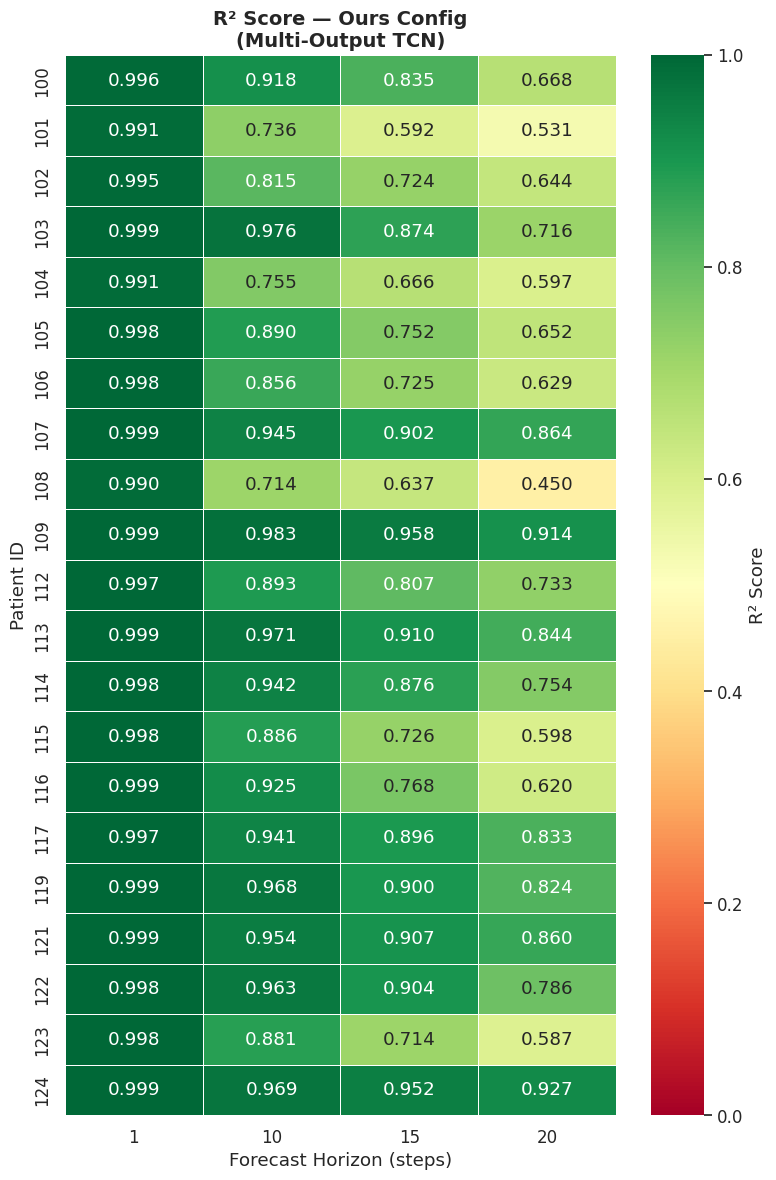

In [10]:
pivot_r2 = df_results.pivot(index='Patient', columns='Horizon', values='R2')

fig, ax = plt.subplots(figsize=(8, 12))
sns.heatmap(
    pivot_r2, annot=True, fmt='.3f', cmap='RdYlGn', center=0.5,
    linewidths=0.5, ax=ax, vmin=0, vmax=1,
    cbar_kws={'label': 'R² Score'}
)
ax.set_title(f'R² Score — {CONFIG_NAME} Config\n(Multi-Output TCN)', fontsize=14, fontweight='bold')
ax.set_ylabel('Patient ID')
ax.set_xlabel('Forecast Horizon (steps)')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/heatmap_r2.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.2 — RMSE Heatmap

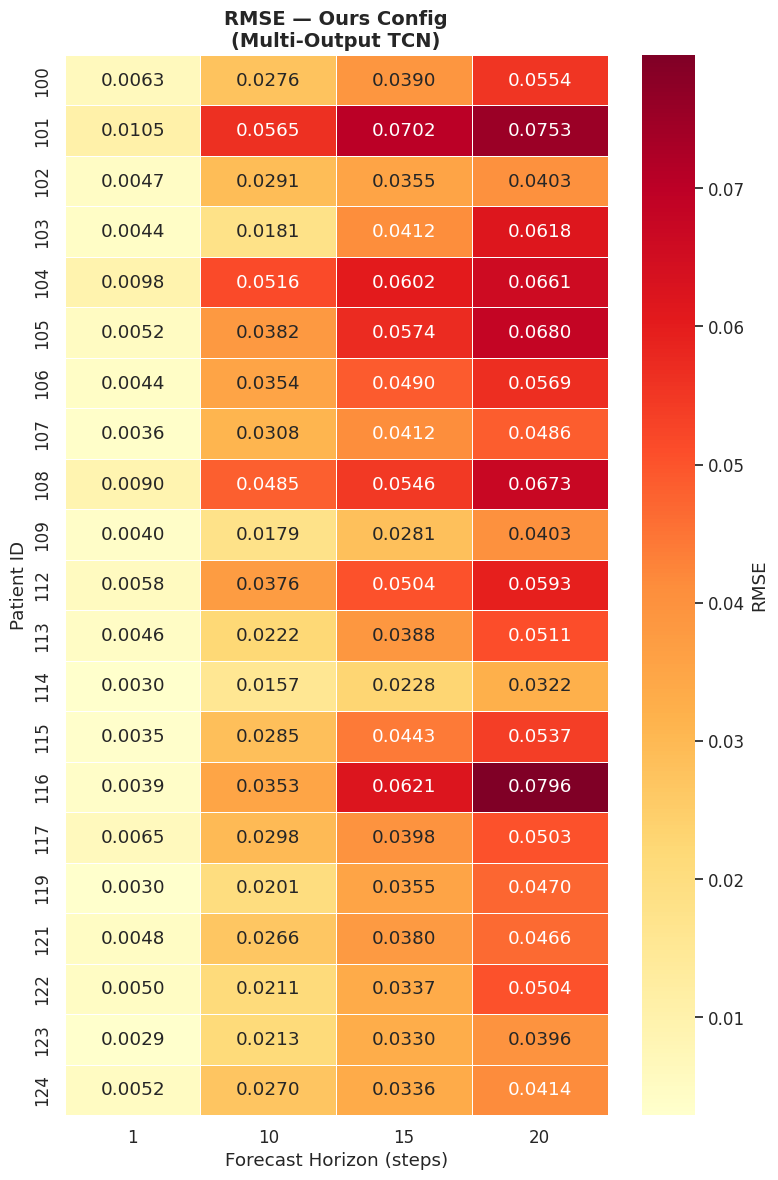

In [11]:
pivot_rmse = df_results.pivot(index='Patient', columns='Horizon', values='RMSE')

fig, ax = plt.subplots(figsize=(8, 12))
sns.heatmap(
    pivot_rmse, annot=True, fmt='.4f', cmap='YlOrRd',
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'RMSE'}
)
ax.set_title(f'RMSE — {CONFIG_NAME} Config\n(Multi-Output TCN)', fontsize=14, fontweight='bold')
ax.set_ylabel('Patient ID')
ax.set_xlabel('Forecast Horizon (steps)')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/heatmap_rmse.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.3 — Box Plots: Metric Distributions per Horizon

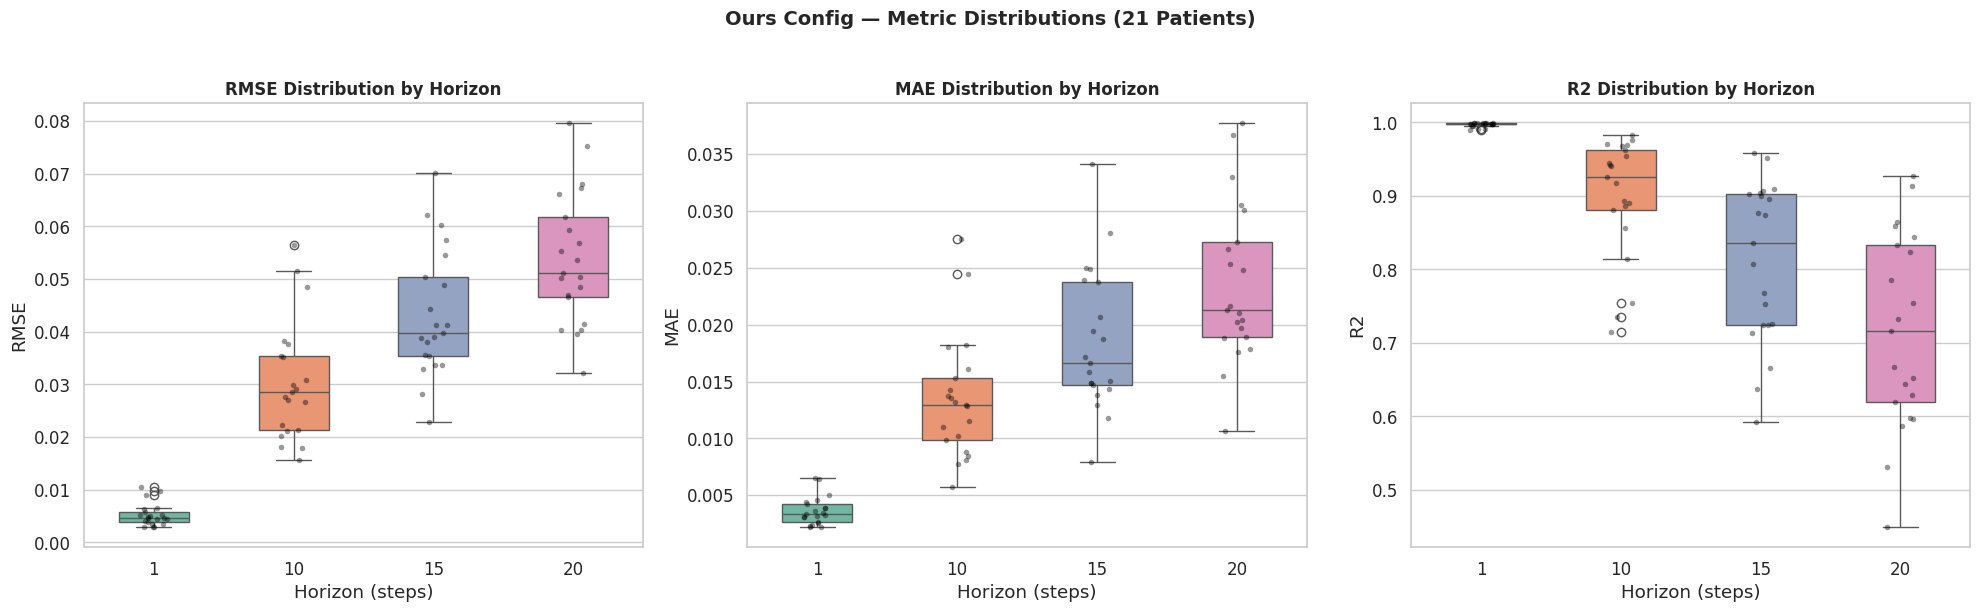

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, metric in zip(axes, ['RMSE', 'MAE', 'R2']):
    sns.boxplot(data=df_results, x='Horizon', y=metric, ax=ax, palette='Set2', width=0.5)
    sns.stripplot(data=df_results, x='Horizon', y=metric, ax=ax,
                  color='black', alpha=0.4, size=4, jitter=True)
    ax.set_title(f'{metric} Distribution by Horizon', fontsize=12, fontweight='bold')
    ax.set_xlabel('Horizon (steps)')
    ax.set_ylabel(metric)

fig.suptitle(f'{CONFIG_NAME} Config — Metric Distributions (21 Patients)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/boxplots_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.4 — Bar Chart: Mean Metrics by Horizon (with error bars)

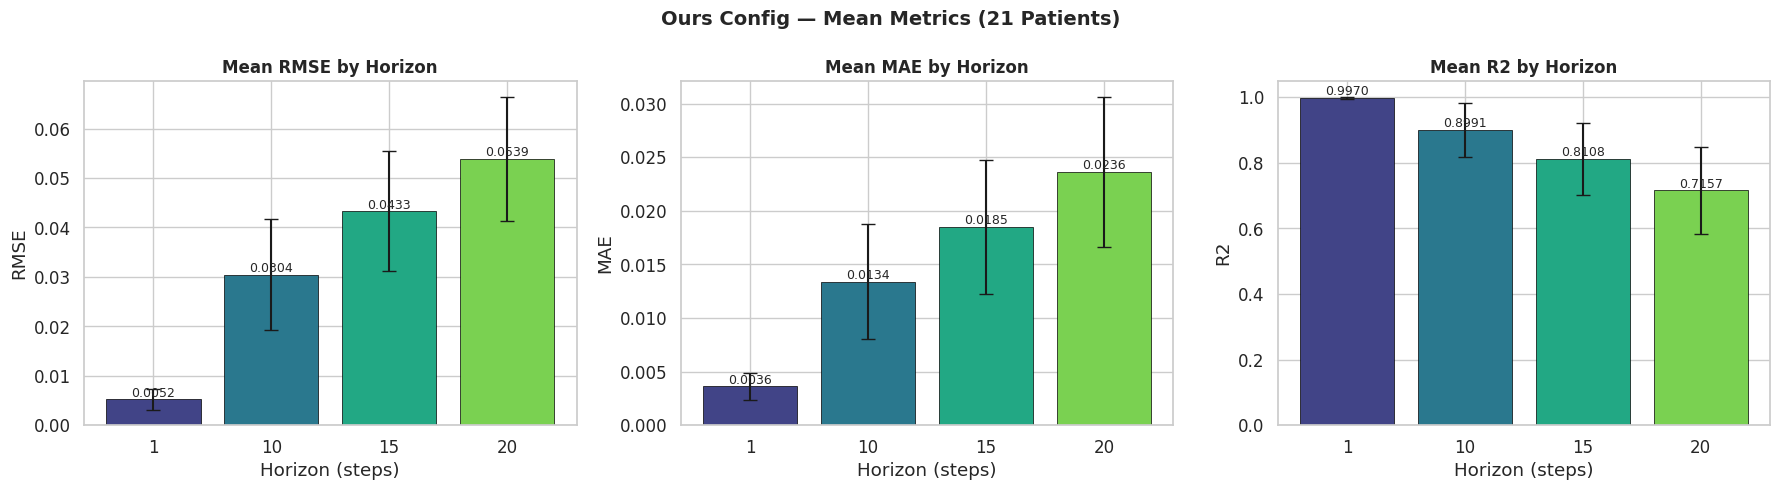

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, ['RMSE', 'MAE', 'R2']):
    means = df_results.groupby('Horizon')[metric].mean()
    stds  = df_results.groupby('Horizon')[metric].std()
    colors = sns.color_palette('viridis', len(HORIZONS))

    bars = ax.bar(range(len(HORIZONS)), means.values, yerr=stds.values,
                  capsize=5, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(len(HORIZONS)))
    ax.set_xticklabels([str(h) for h in HORIZONS])
    ax.set_title(f'Mean {metric} by Horizon', fontsize=12, fontweight='bold')
    ax.set_xlabel('Horizon (steps)')
    ax.set_ylabel(metric)
    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)

fig.suptitle(f'{CONFIG_NAME} Config — Mean Metrics (21 Patients)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/barchart_mean_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.5 — Per-Step RMSE Degradation

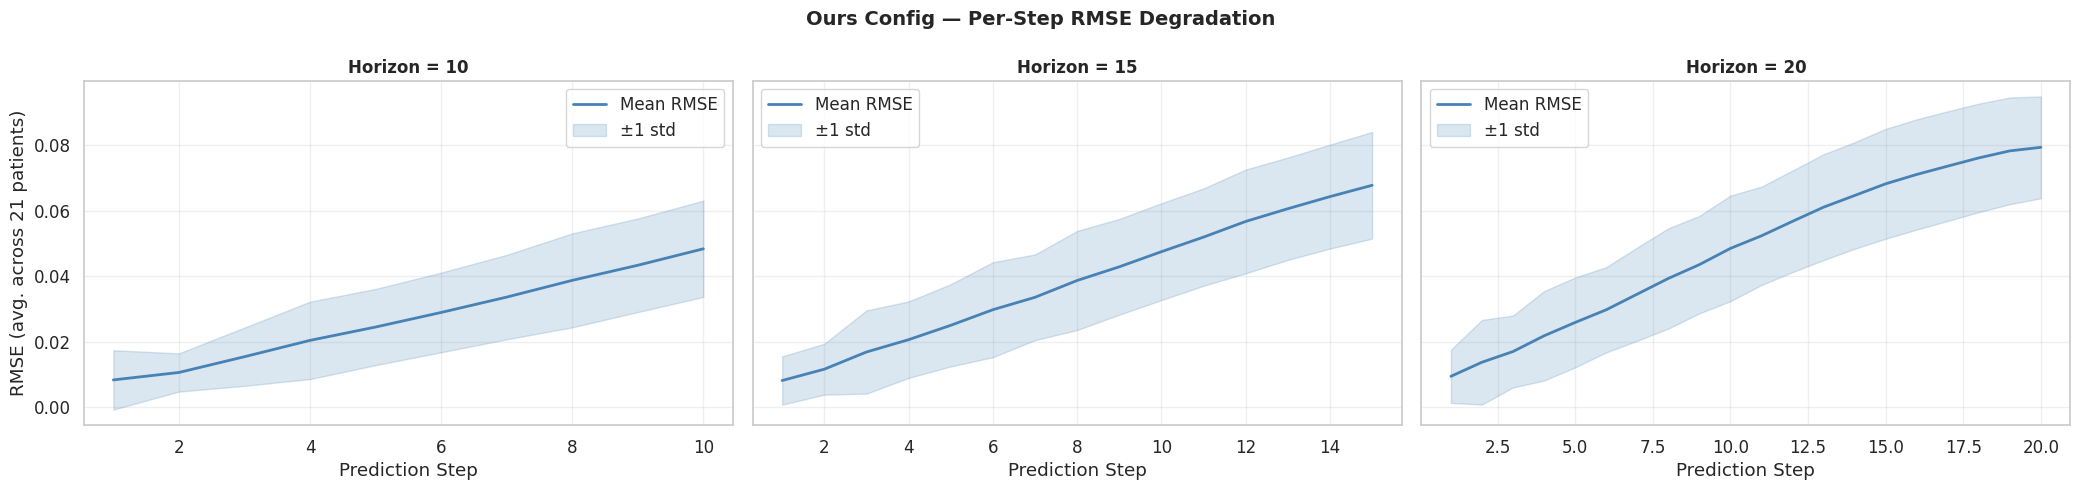

In [14]:
multi_step_horizons = [h for h in HORIZONS if h > 1]
fig, axes = plt.subplots(1, len(multi_step_horizons),
                         figsize=(7 * len(multi_step_horizons), 5), sharey=True)
if len(multi_step_horizons) == 1:
    axes = [axes]

for idx, horizon in enumerate(multi_step_horizons):
    ax = axes[idx]
    step_dfs = [per_step_results[(rid, horizon)]
                for rid in PATIENTS if (rid, horizon) in per_step_results]
    if not step_dfs:
        continue
    combined = pd.concat(step_dfs)
    avg_by_step = combined.groupby('Step')['RMSE'].mean()
    std_by_step = combined.groupby('Step')['RMSE'].std()

    ax.plot(avg_by_step.index, avg_by_step.values, linewidth=2, color='steelblue', label='Mean RMSE')
    ax.fill_between(avg_by_step.index,
                    avg_by_step.values - std_by_step.values,
                    avg_by_step.values + std_by_step.values,
                    alpha=0.2, color='steelblue', label='±1 std')
    ax.set_title(f'Horizon = {horizon}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Prediction Step')
    if idx == 0:
        ax.set_ylabel('RMSE (avg. across 21 patients)')
    ax.legend()
    ax.grid(alpha=0.3)

fig.suptitle(f'{CONFIG_NAME} Config — Per-Step RMSE Degradation',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/per_step_rmse.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.6 — Per-Step R² Degradation (all horizons overlaid)

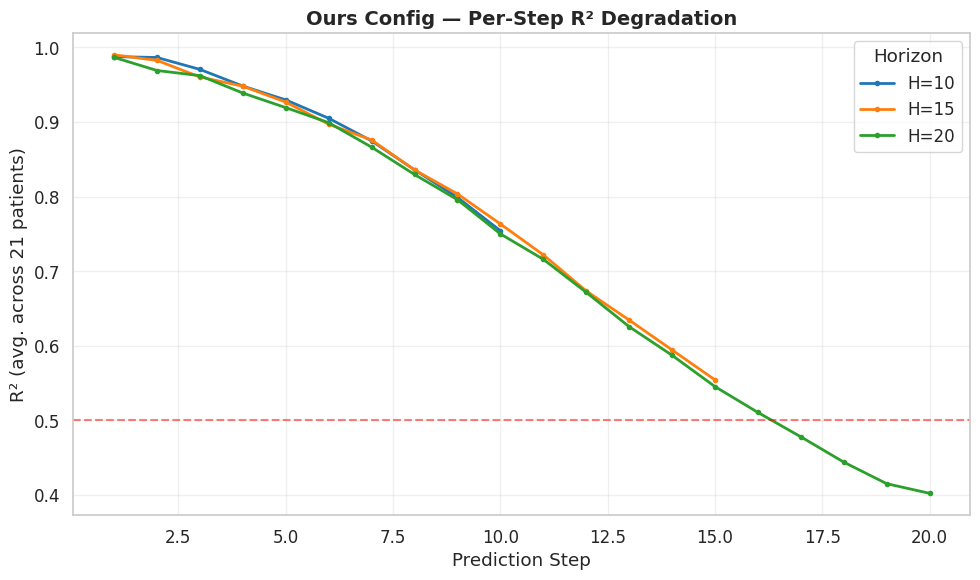

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette('tab10', len(multi_step_horizons))

for idx, horizon in enumerate(multi_step_horizons):
    step_dfs = [per_step_results[(rid, horizon)]
                for rid in PATIENTS if (rid, horizon) in per_step_results]
    if not step_dfs:
        continue
    combined = pd.concat(step_dfs)
    avg_r2 = combined.groupby('Step')['R2'].mean()
    ax.plot(avg_r2.index, avg_r2.values, linewidth=2, color=colors[idx],
            marker='o', markersize=3, label=f'H={horizon}')

ax.set_title(f'{CONFIG_NAME} Config — Per-Step R² Degradation', fontsize=14, fontweight='bold')
ax.set_xlabel('Prediction Step')
ax.set_ylabel('R² (avg. across 21 patients)')
ax.legend(title='Horizon')
ax.grid(alpha=0.3)
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/per_step_r2_overlay.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.7 — Actual vs Predicted (Representative Patients)

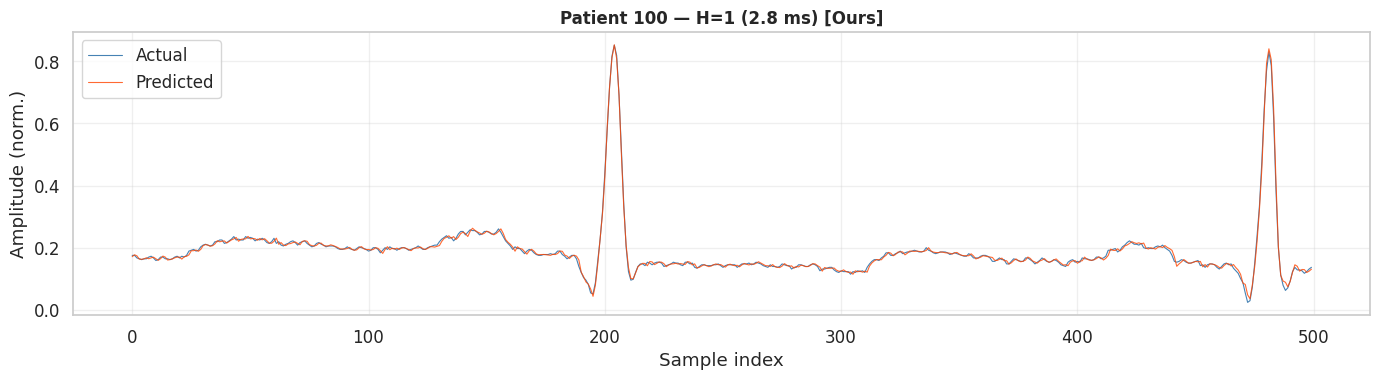

  Saved: plots_ours/pred_100_MO_H1.png


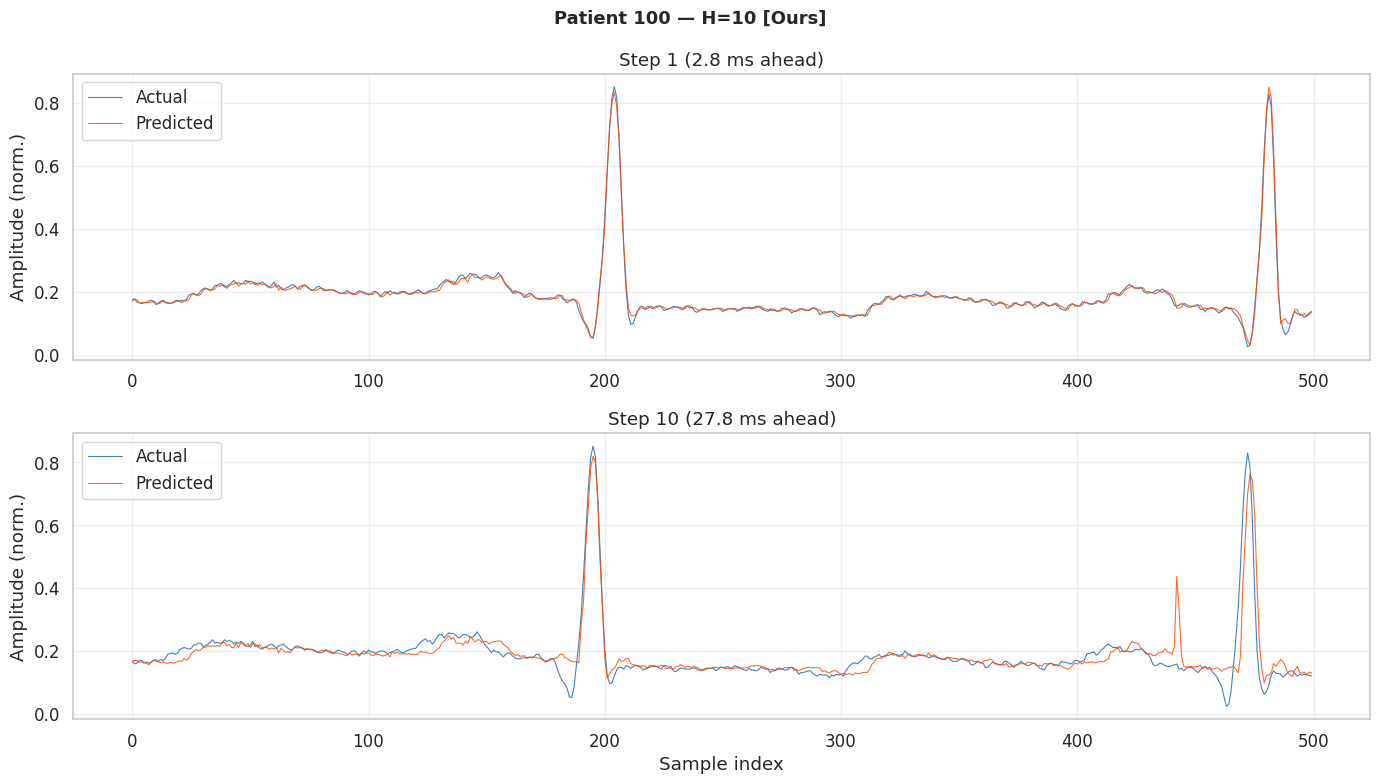

  Saved: plots_ours/pred_100_MO_H10.png


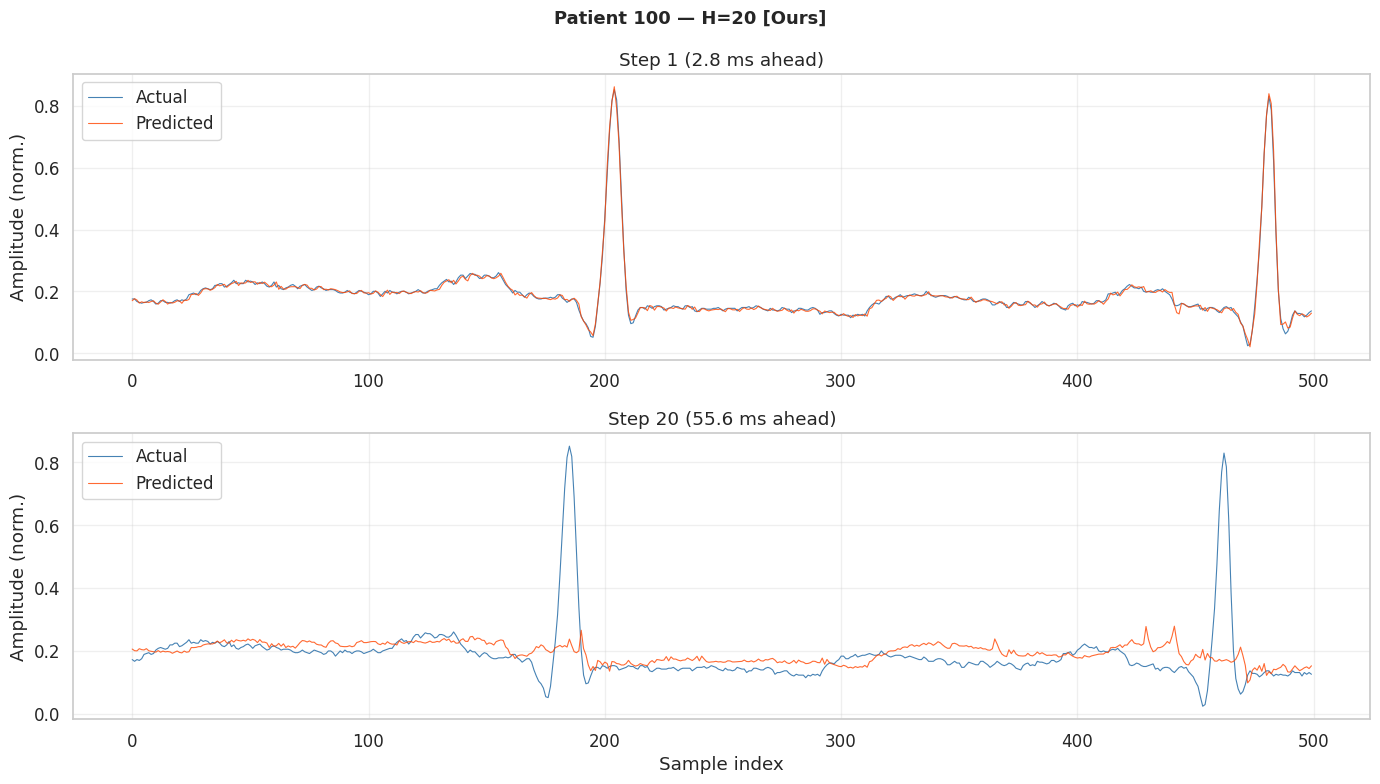

  Saved: plots_ours/pred_100_MO_H20.png


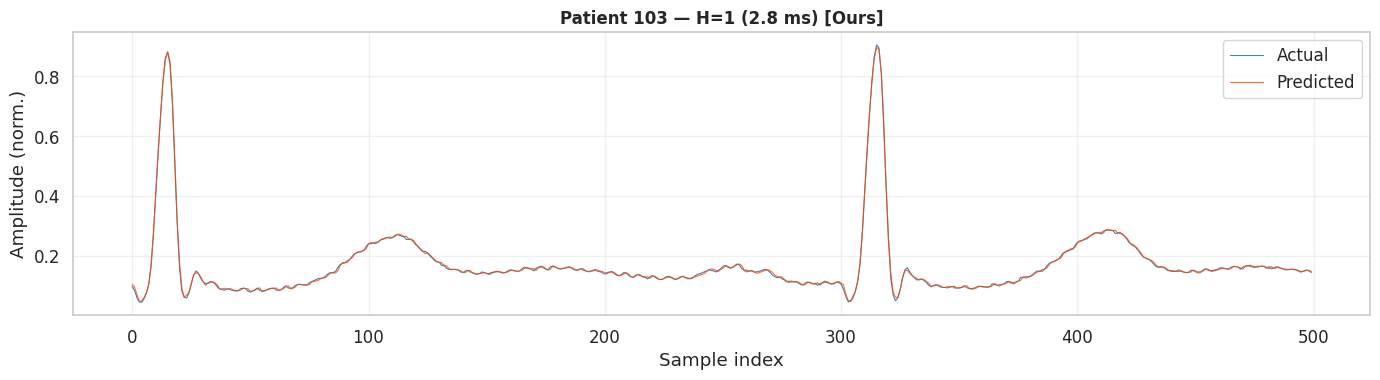

  Saved: plots_ours/pred_103_MO_H1.png


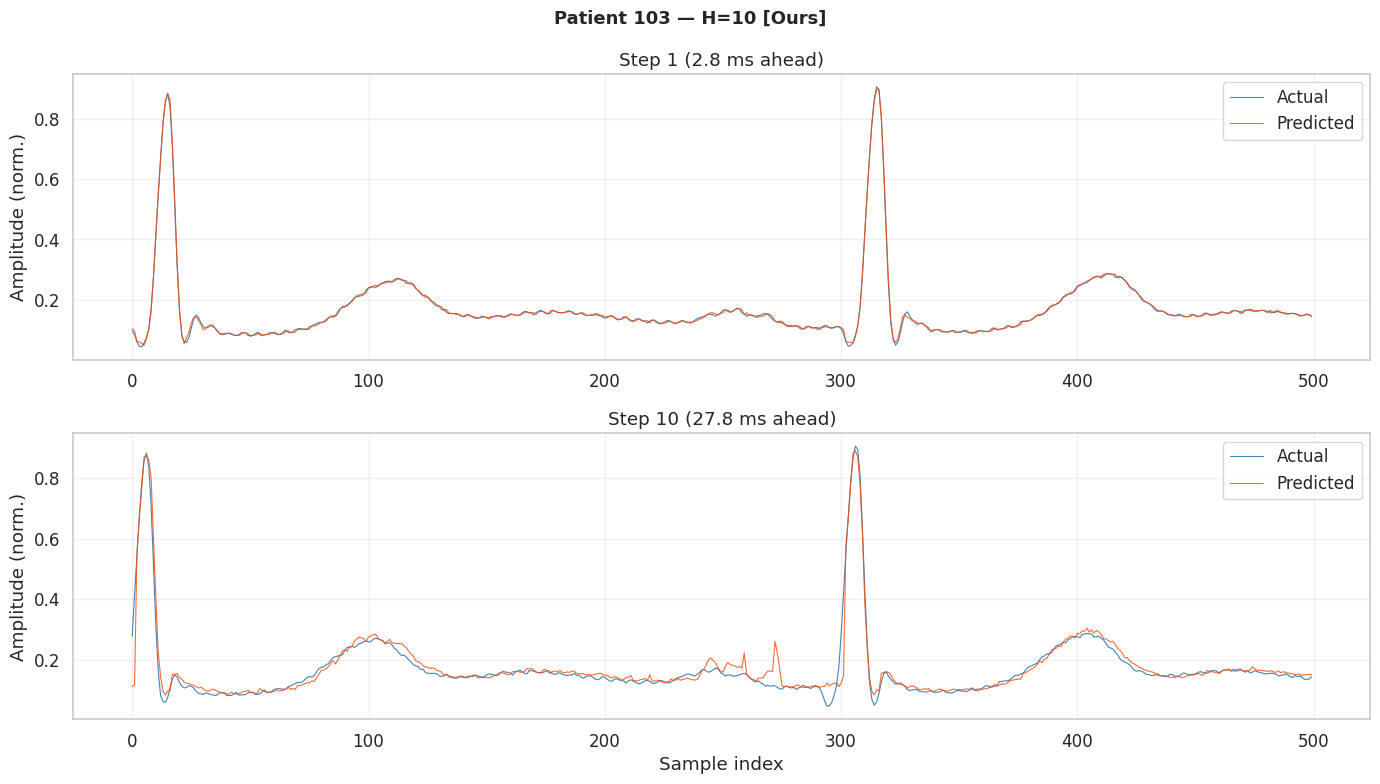

  Saved: plots_ours/pred_103_MO_H10.png


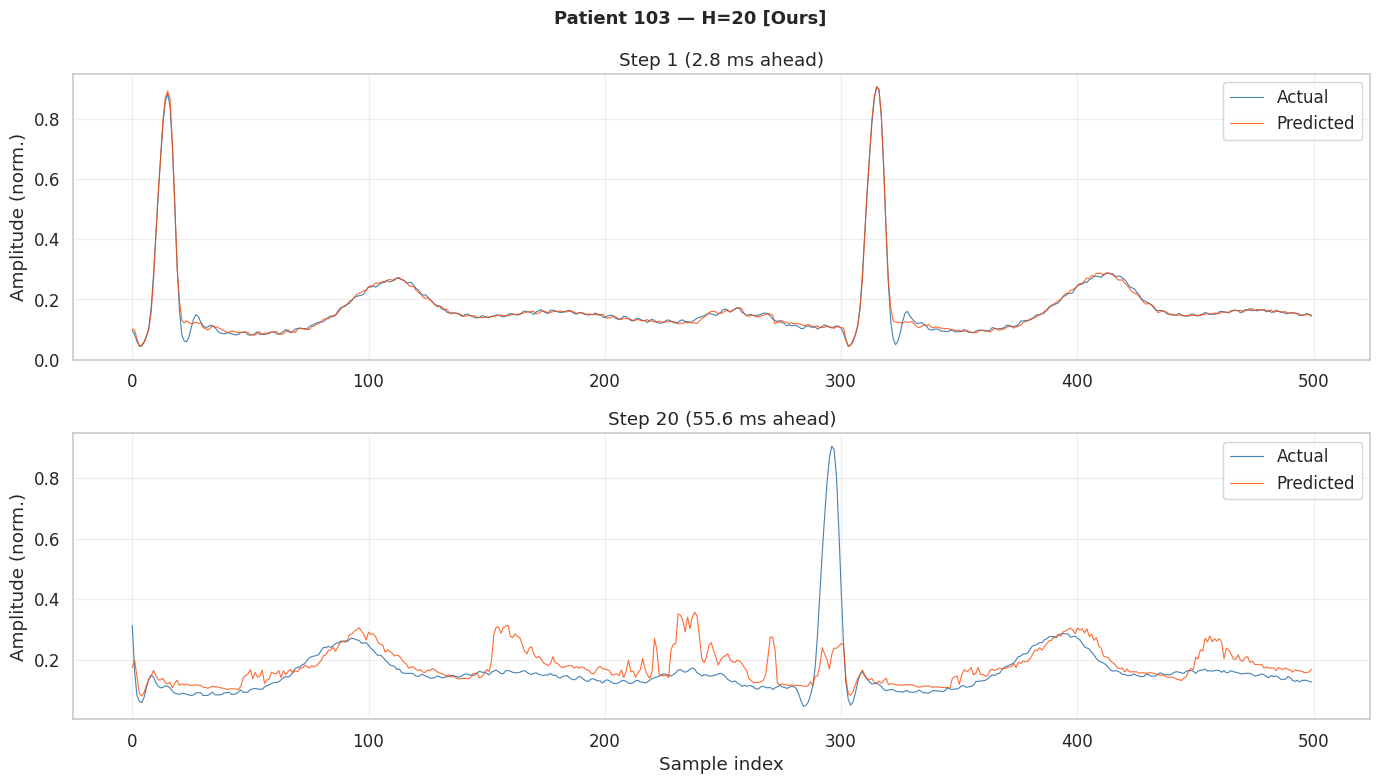

  Saved: plots_ours/pred_103_MO_H20.png


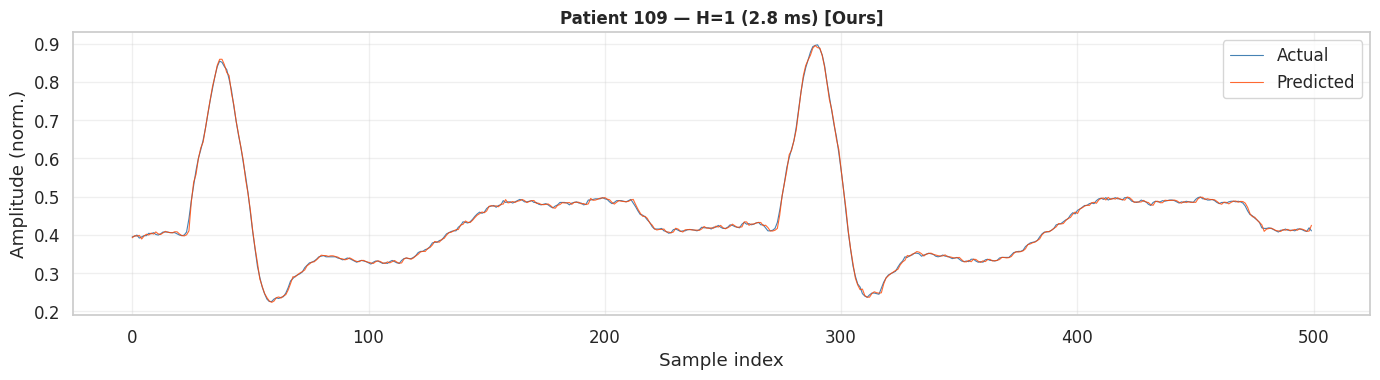

  Saved: plots_ours/pred_109_MO_H1.png


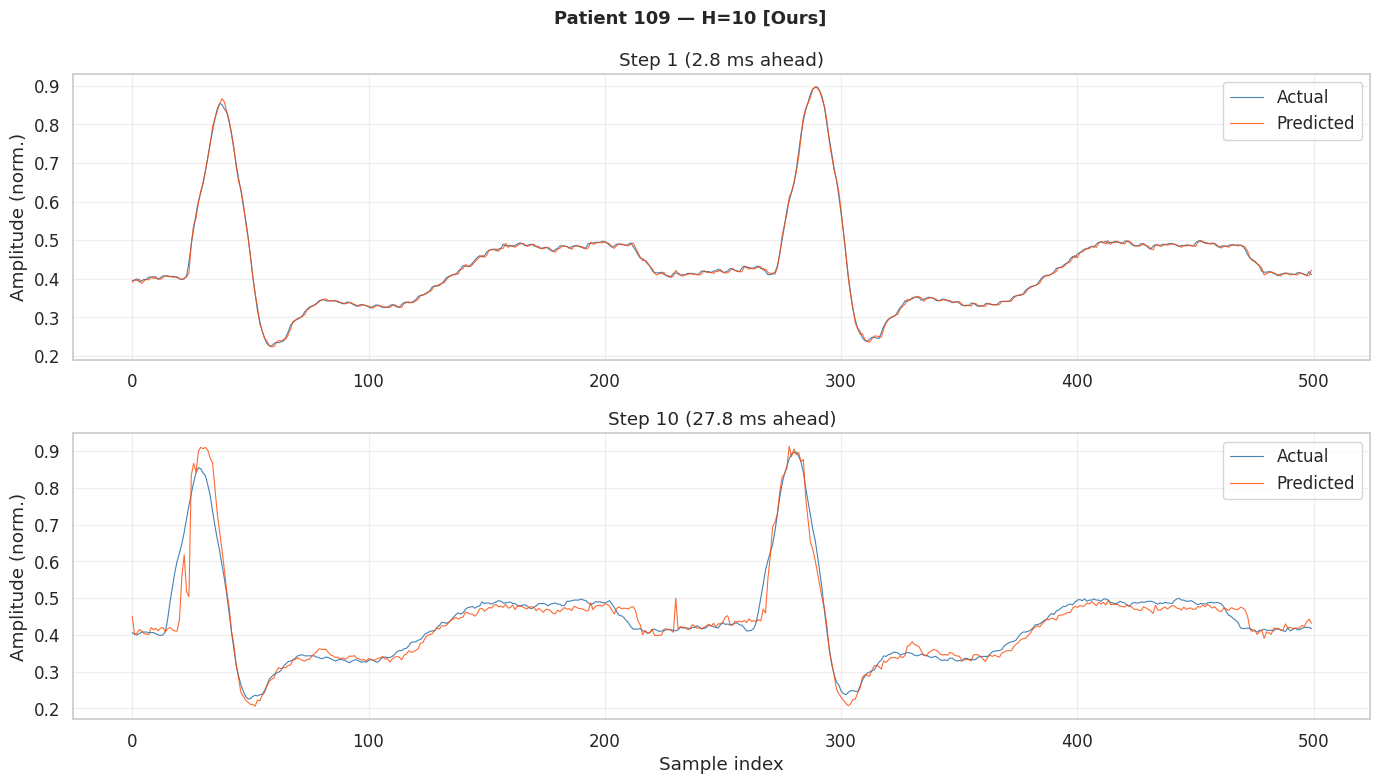

  Saved: plots_ours/pred_109_MO_H10.png


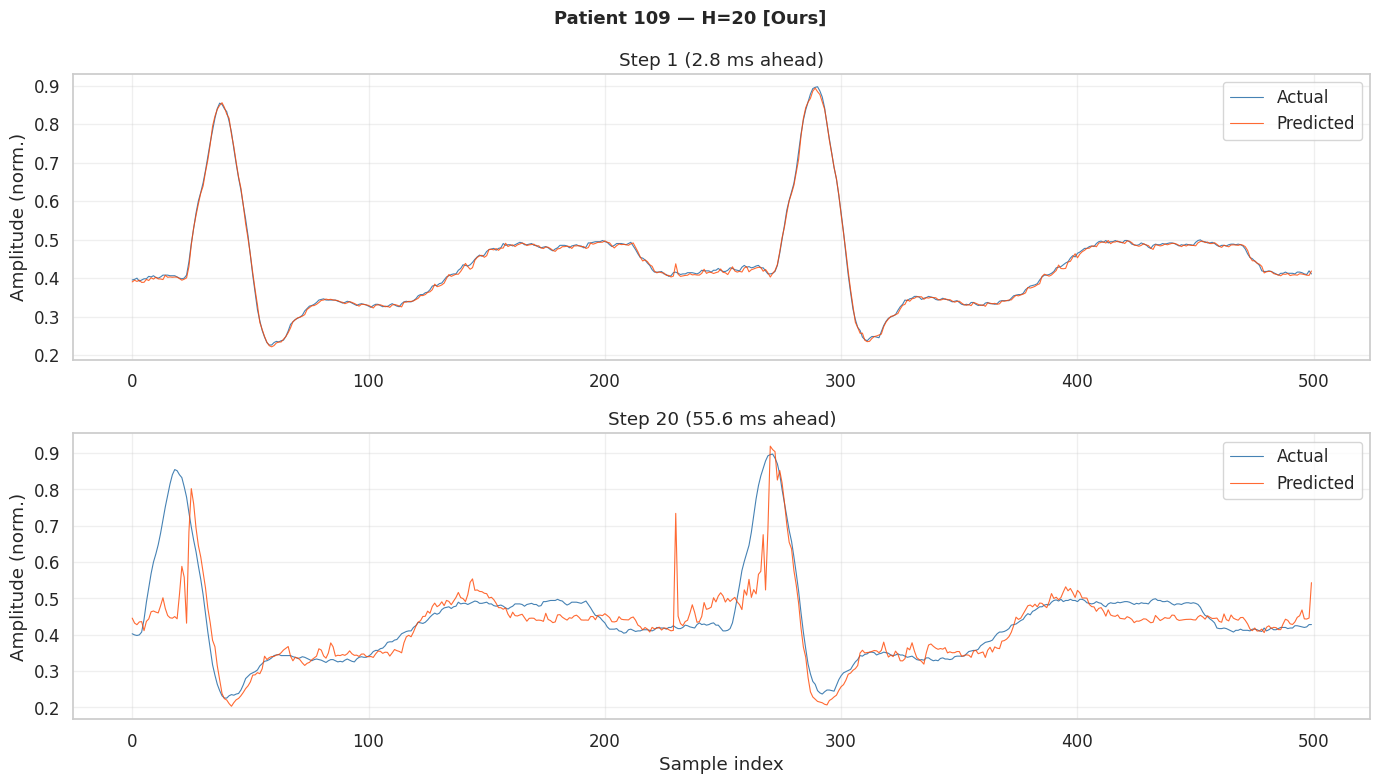

  Saved: plots_ours/pred_109_MO_H20.png


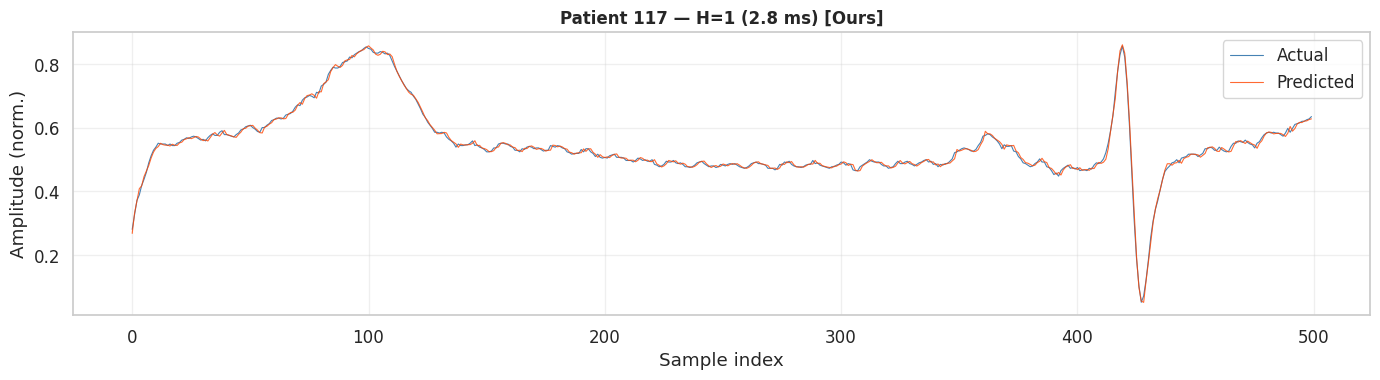

  Saved: plots_ours/pred_117_MO_H1.png


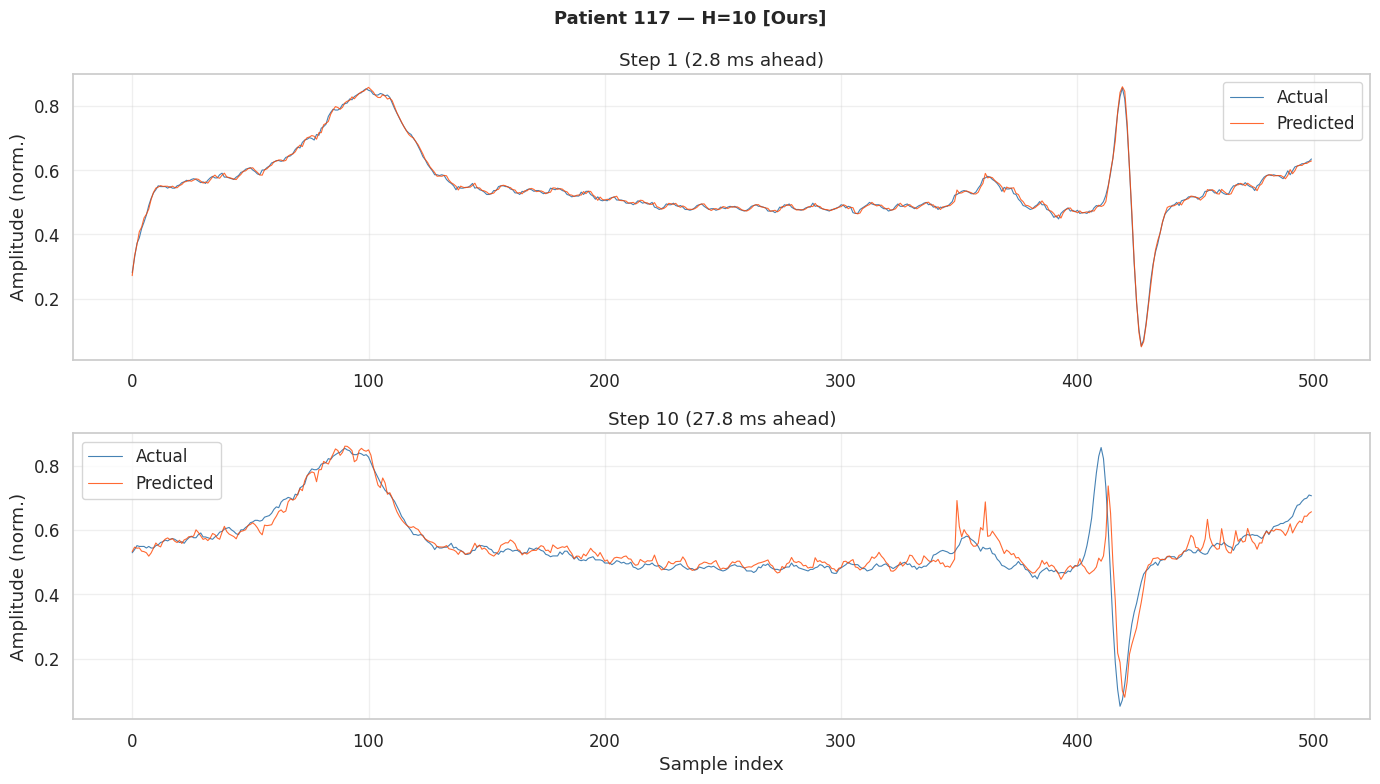

  Saved: plots_ours/pred_117_MO_H10.png


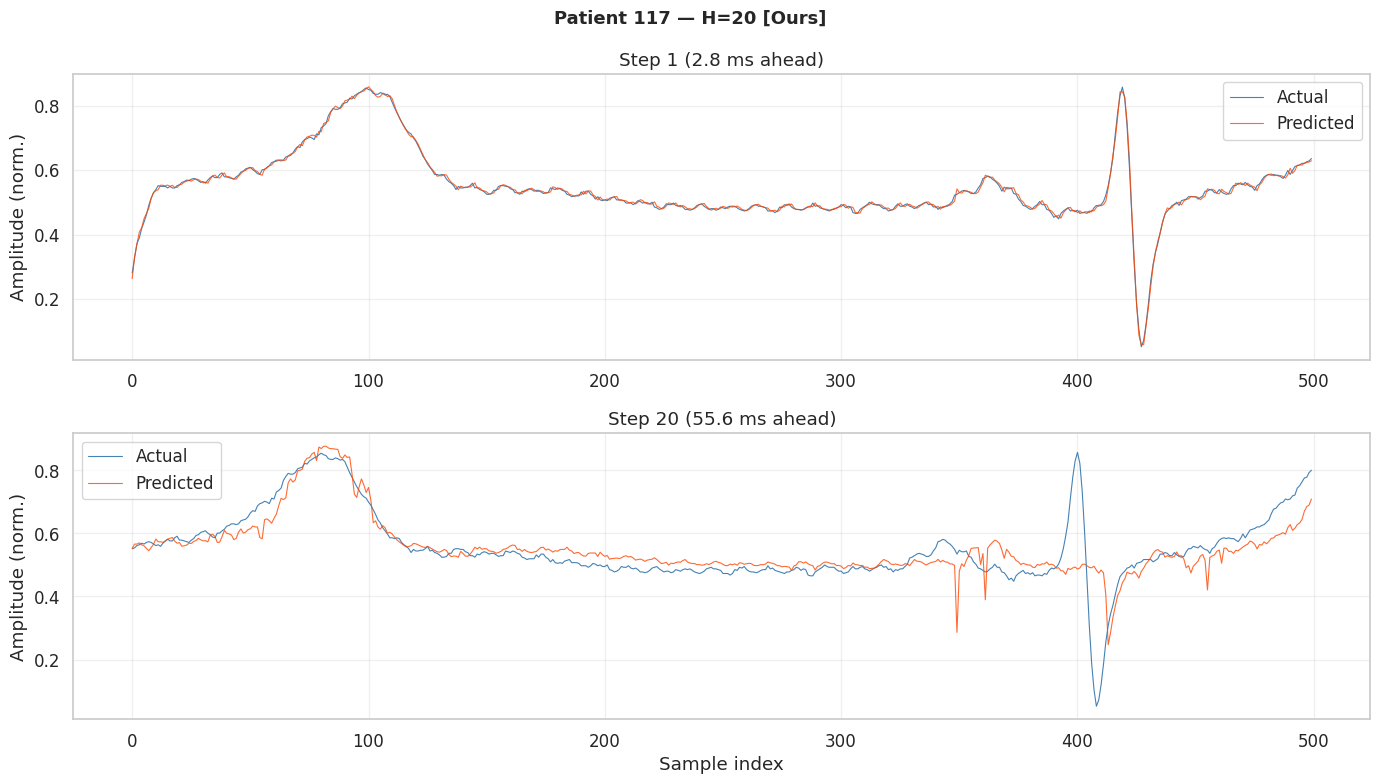

  Saved: plots_ours/pred_117_MO_H20.png


In [16]:
VIZ_PATIENTS = ['100', '103', '109', '117']
VIZ_HORIZONS = [1, 10, 20]

for rid in VIZ_PATIENTS:
    for horizon in VIZ_HORIZONS:
        key = (rid, horizon)
        if key not in saved_preds:
            continue
        y_te, preds = saved_preds[key]
        n_show = min(500, len(y_te))

        if horizon == 1:
            fig, ax = plt.subplots(figsize=(14, 4))
            ax.plot(y_te[:n_show].flatten(), label='Actual', linewidth=0.8, color='steelblue')
            ax.plot(preds[:n_show].flatten(), label='Predicted', linewidth=0.8, color='orangered', alpha=0.8)
            ax.set_title(f'Patient {rid} — H=1 ({1/FS*1000:.1f} ms) [{CONFIG_NAME}]',
                         fontsize=12, fontweight='bold')
            ax.legend(); ax.set_ylabel('Amplitude (norm.)')
            ax.set_xlabel('Sample index'); ax.grid(alpha=0.3)
        else:
            fig, axes = plt.subplots(2, 1, figsize=(14, 8))
            axes[0].plot(y_te[:n_show, 0], label='Actual', linewidth=0.8, color='steelblue')
            axes[0].plot(preds[:n_show, 0], label='Predicted', linewidth=0.8, color='orangered', alpha=0.8)
            axes[0].set_title(f'Step 1 ({1/FS*1000:.1f} ms ahead)')
            axes[0].legend(); axes[0].set_ylabel('Amplitude (norm.)'); axes[0].grid(alpha=0.3)

            last = horizon - 1
            axes[1].plot(y_te[:n_show, last], label='Actual', linewidth=0.8, color='steelblue')
            axes[1].plot(preds[:n_show, last], label='Predicted', linewidth=0.8, color='orangered', alpha=0.8)
            axes[1].set_title(f'Step {horizon} ({horizon/FS*1000:.1f} ms ahead)')
            axes[1].legend(); axes[1].set_ylabel('Amplitude (norm.)')
            axes[1].set_xlabel('Sample index'); axes[1].grid(alpha=0.3)

            fig.suptitle(f'Patient {rid} — H={horizon} [{CONFIG_NAME}]',
                         fontsize=13, fontweight='bold')

        plt.tight_layout()
        fname = f'{PLOT_DIR}/pred_{rid}_MO_H{horizon}.png'
        plt.savefig(fname, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'  Saved: {fname}')

### 7.8 — Training Loss Curves

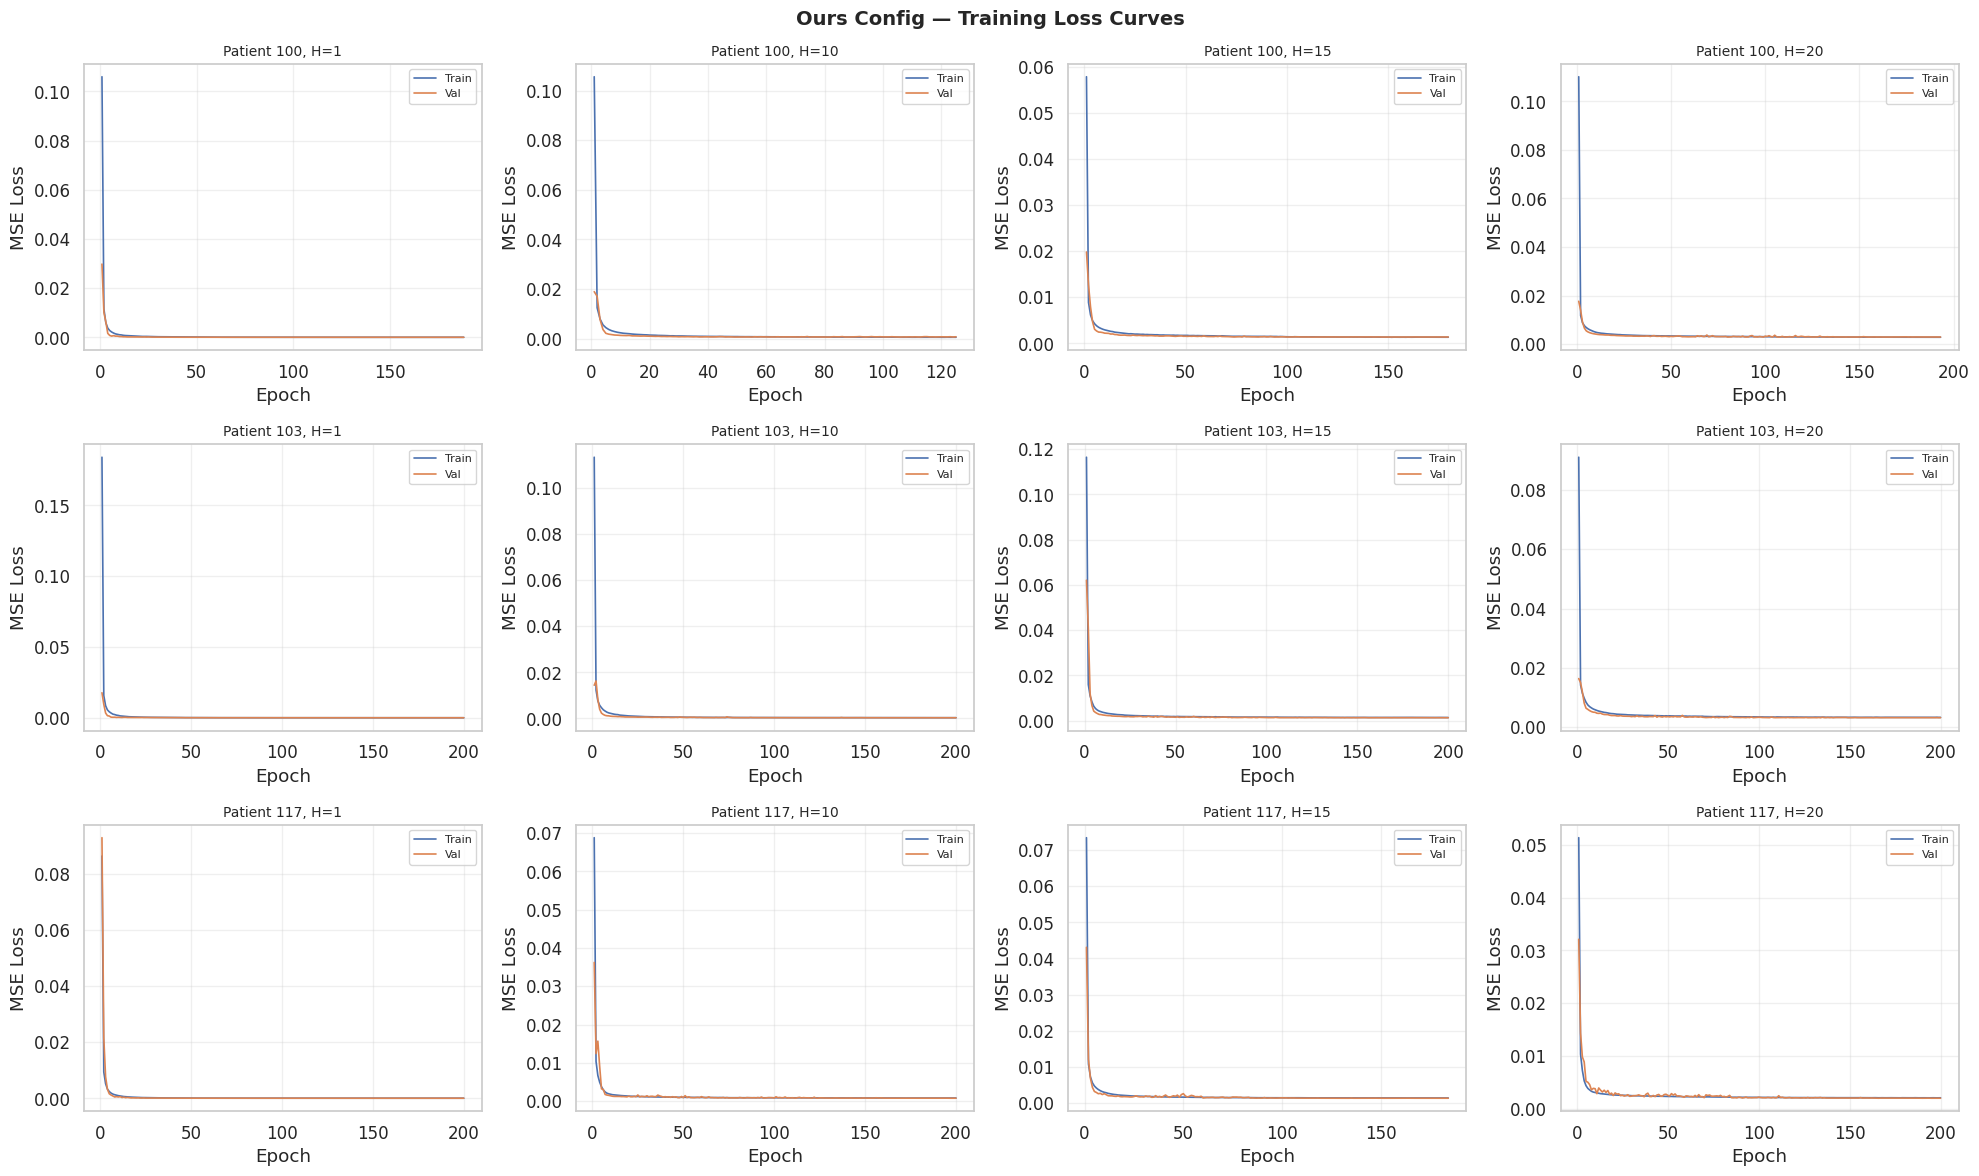

In [17]:
LOSS_VIZ_PATIENTS = ['100', '103', '117']

fig, axes = plt.subplots(len(LOSS_VIZ_PATIENTS), len(HORIZONS),
                         figsize=(5 * len(HORIZONS), 4 * len(LOSS_VIZ_PATIENTS)))

for row, rid in enumerate(LOSS_VIZ_PATIENTS):
    for col, horizon in enumerate(HORIZONS):
        ax = axes[row, col]
        key = (rid, horizon)
        if key not in training_histories:
            continue
        hist = training_histories[key]
        epochs_ran = range(1, len(hist['loss']) + 1)
        ax.plot(epochs_ran, hist['loss'], label='Train', linewidth=1.2)
        ax.plot(epochs_ran, hist['val_loss'], label='Val', linewidth=1.2)
        ax.set_title(f'Patient {rid}, H={horizon}', fontsize=10)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('MSE Loss')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

fig.suptitle(f'{CONFIG_NAME} Config — Training Loss Curves',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/training_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.9 — Error Distribution Histograms

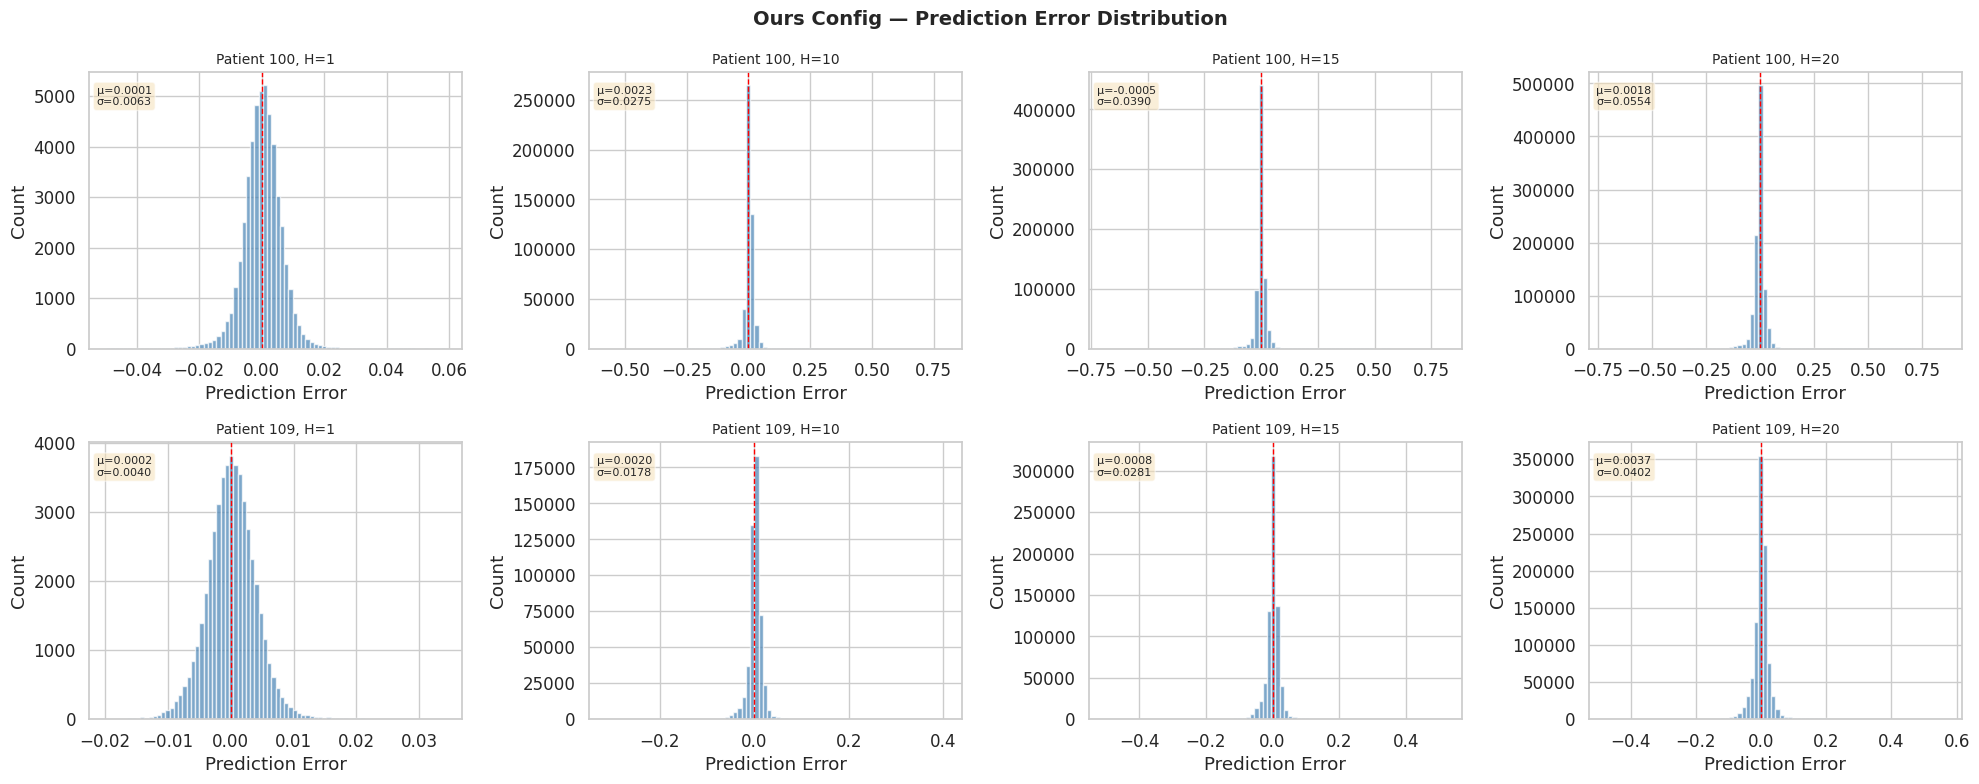

In [18]:
ERR_VIZ_PATIENTS = ['100', '109']

fig, axes = plt.subplots(len(ERR_VIZ_PATIENTS), len(HORIZONS),
                         figsize=(5 * len(HORIZONS), 4 * len(ERR_VIZ_PATIENTS)))

for row, rid in enumerate(ERR_VIZ_PATIENTS):
    for col, horizon in enumerate(HORIZONS):
        ax = axes[row, col]
        key = (rid, horizon)
        if key not in saved_preds:
            continue
        y_te, preds = saved_preds[key]
        errors = (y_te - preds).flatten()
        ax.hist(errors, bins=80, color='steelblue', alpha=0.7, edgecolor='white')
        ax.axvline(x=0, color='red', linestyle='--', linewidth=1)
        ax.set_title(f'Patient {rid}, H={horizon}', fontsize=10)
        ax.set_xlabel('Prediction Error')
        ax.set_ylabel('Count')
        ax.text(0.02, 0.95, f'μ={errors.mean():.4f}\nσ={errors.std():.4f}',
                transform=ax.transAxes, fontsize=8, va='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig.suptitle(f'{CONFIG_NAME} Config — Prediction Error Distribution',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/error_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.10 — Patient Ranking: R² per Horizon

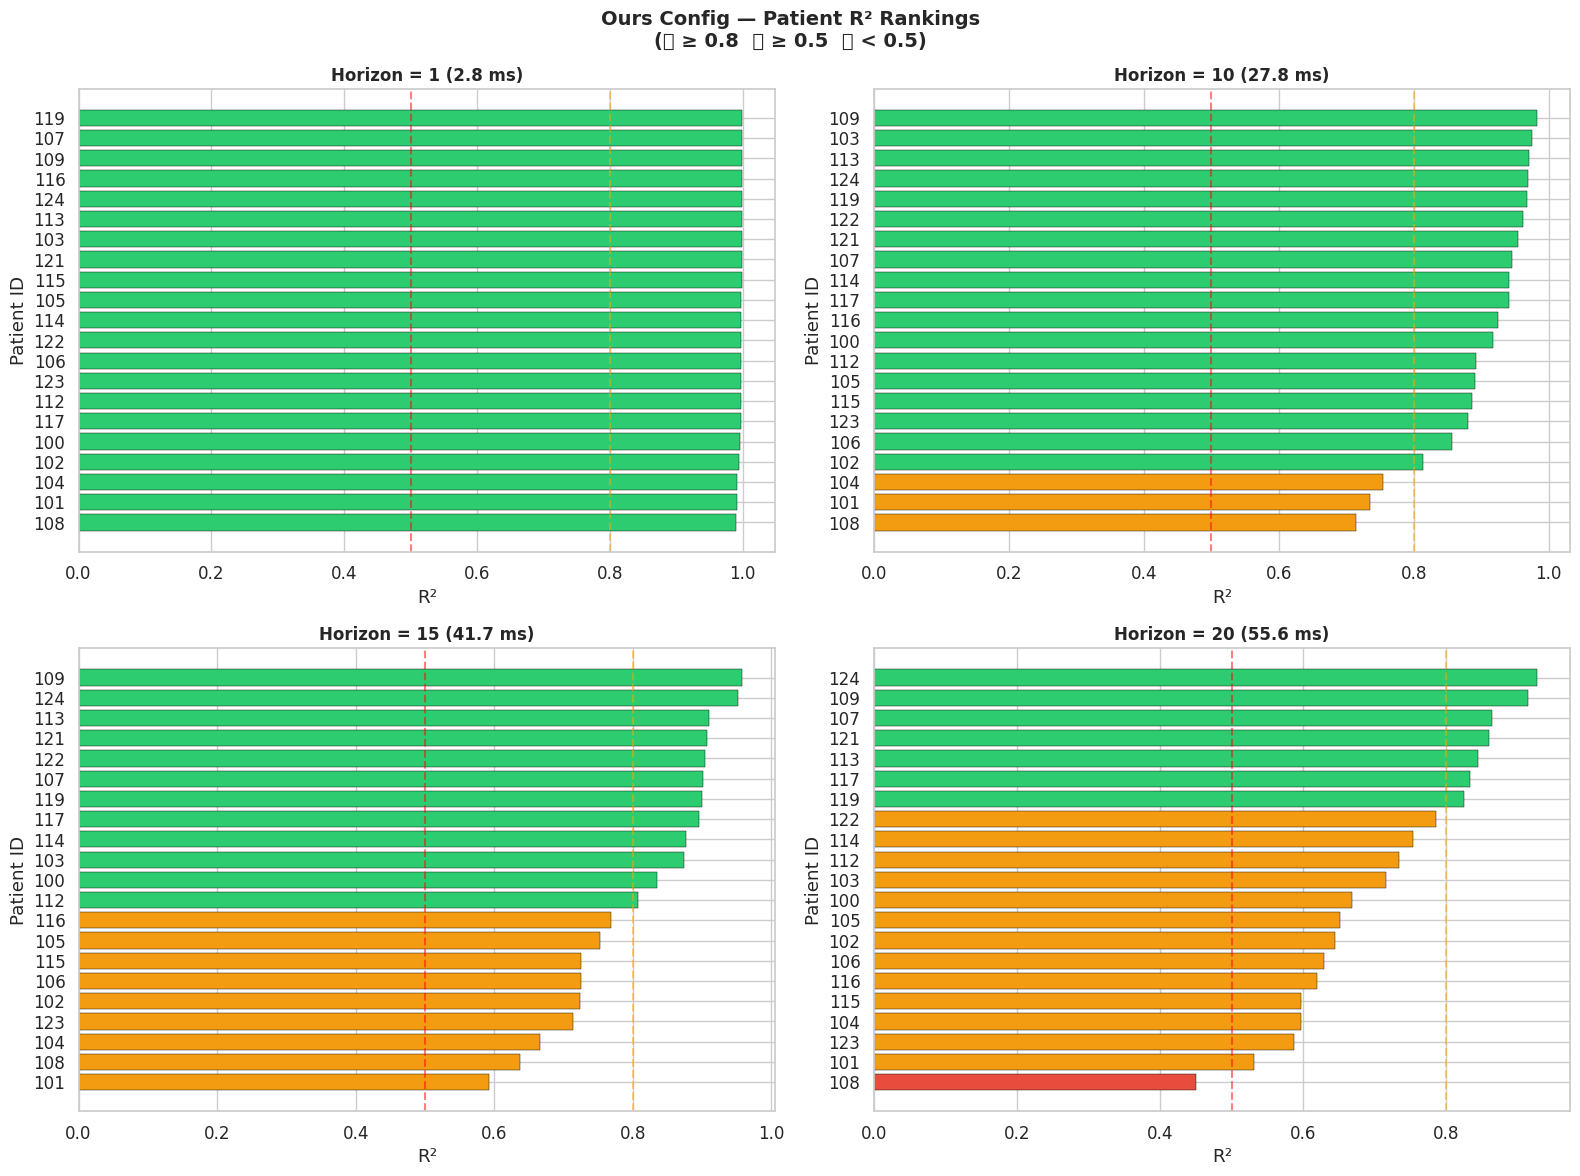

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, horizon in zip(axes.flatten(), HORIZONS):
    df_h = df_results[df_results['Horizon'] == horizon].sort_values('R2', ascending=True)
    colors = ['#e74c3c' if r2 < 0.5 else '#f39c12' if r2 < 0.8 else '#2ecc71'
              for r2 in df_h['R2']]
    ax.barh(df_h['Patient'], df_h['R2'], color=colors, edgecolor='black', linewidth=0.3)
    ax.set_title(f'Horizon = {horizon} ({horizon/FS*1000:.1f} ms)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('R²')
    ax.set_ylabel('Patient ID')
    ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.5)
    ax.axvline(x=0.8, color='orange', linestyle='--', alpha=0.5)
    ax.set_xlim(left=min(0, df_h['R2'].min() - 0.05))

fig.suptitle(f'{CONFIG_NAME} Config — Patient R² Rankings\n'
             '(🟢 ≥ 0.8  🟡 ≥ 0.5  🔴 < 0.5)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/patient_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.11 — Scatter: RMSE vs R²

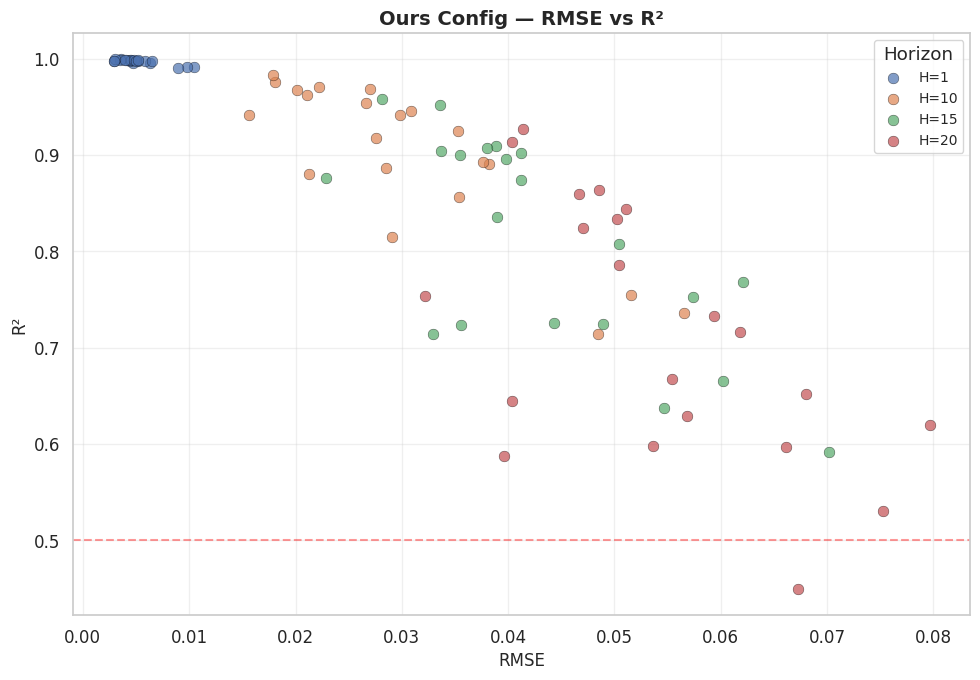

In [20]:
fig, ax = plt.subplots(figsize=(10, 7))

for horizon in HORIZONS:
    df_h = df_results[df_results['Horizon'] == horizon]
    ax.scatter(df_h['RMSE'], df_h['R2'], s=60, alpha=0.7,
               label=f'H={horizon}', edgecolors='black', linewidth=0.3)

ax.set_xlabel('RMSE', fontsize=12)
ax.set_ylabel('R²', fontsize=12)
ax.set_title(f'{CONFIG_NAME} Config — RMSE vs R²', fontsize=14, fontweight='bold')
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.4)
ax.legend(title='Horizon', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/scatter_rmse_vs_r2.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.12 — Violin Plots: R² per Horizon

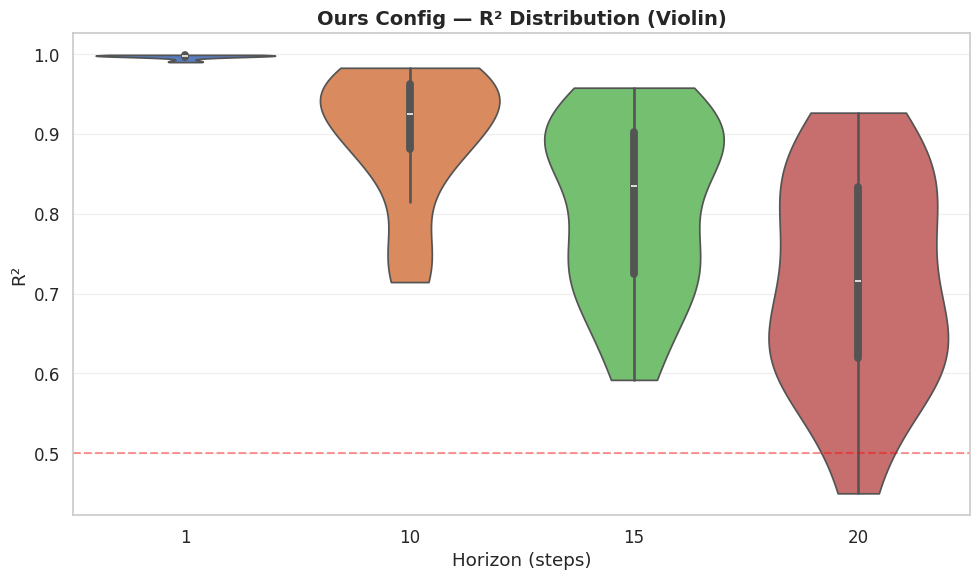

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(data=df_results, x='Horizon', y='R2', ax=ax, palette='muted', inner='box', cut=0)
ax.set_title(f'{CONFIG_NAME} Config — R² Distribution (Violin)', fontsize=14, fontweight='bold')
ax.set_xlabel('Horizon (steps)')
ax.set_ylabel('R²')
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.4)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/violin_r2.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.13 — Radar Chart

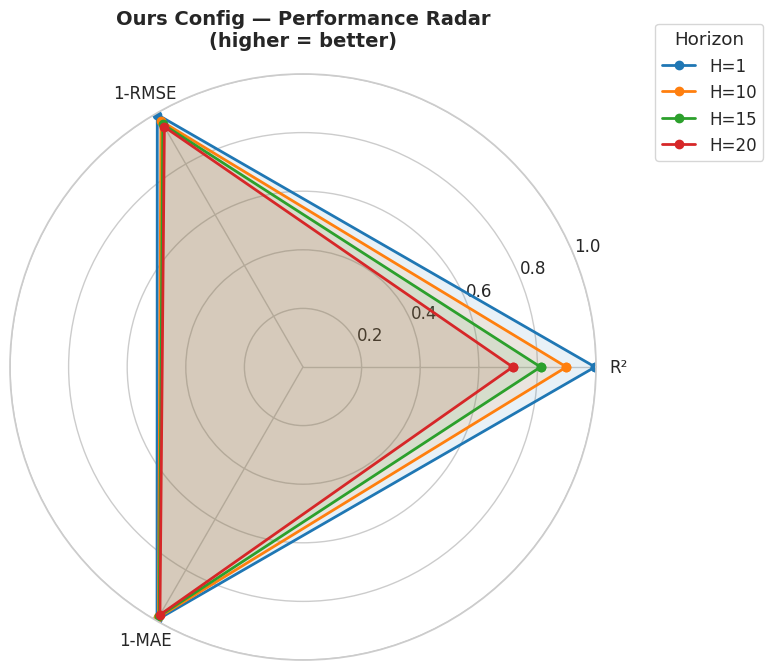

In [22]:
from math import pi

categories = ['R²', '1-RMSE', '1-MAE']
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = sns.color_palette('tab10', len(HORIZONS))

for idx, horizon in enumerate(HORIZONS):
    df_h = df_results[df_results['Horizon'] == horizon]
    values = [max(0, df_h['R2'].mean()), max(0, 1 - df_h['RMSE'].mean()), max(0, 1 - df_h['MAE'].mean())]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=f'H={horizon}', color=colors[idx])
    ax.fill(angles, values, alpha=0.1, color=colors[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0, 1)
ax.set_title(f'{CONFIG_NAME} Config — Performance Radar\n(higher = better)',
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), title='Horizon')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Convergence Analysis

Section 7.8 plots raw loss curves for 3 patients. This section uses **all 84 runs** (21 patients × 4 horizons) to answer questions those plots cannot: how many epochs training actually needs, whether the 200-epoch budget and patience of 50 are right, whether any run overfits, and whether slower convergence buys better accuracy.

All quantities are read from `training_histories`, so nothing is retrained.

In [ ]:
# ── 8.1 Per-run convergence table ────────────────────────────────────────────
# Early stopping restores the best weights, so the epoch of minimum val_loss is
# the epoch that produced the reported model - not the last epoch run.
import scipy.stats as st

conv_rows = []
for (rid, horizon), hist in training_histories.items():
    loss     = np.asarray(hist['loss'], dtype=float)
    val_loss = np.asarray(hist['val_loss'], dtype=float)
    best_ep  = int(np.argmin(val_loss)) + 1          # 1-indexed
    conv_rows.append({
        'Patient'      : rid,
        'Horizon'      : horizon,
        'epochs_ran'   : len(val_loss),
        'best_epoch'   : best_ep,
        'best_val_loss': float(val_loss[best_ep - 1]),
        'train_at_best': float(loss[best_ep - 1]),
        # >1 means val loss is higher than train loss at the selected epoch
        'gen_gap_ratio': float(val_loss[best_ep - 1] / loss[best_ep - 1]),
        'stopped_early': len(val_loss) < EPOCHS,
        # How much of the final improvement was reached by epoch 20
        'frac_at_ep20' : float(
            (val_loss[0] - val_loss[min(19, len(val_loss) - 1)]) /
            (val_loss[0] - val_loss[best_ep - 1])
        ) if val_loss[0] > val_loss[best_ep - 1] else np.nan,
    })

df_conv = pd.DataFrame(conv_rows).sort_values(['Horizon', 'Patient']).reset_index(drop=True)

df_conv_summary = (
    df_conv.groupby('Horizon')
    .agg(runs           = ('best_epoch', 'size'),
         best_epoch_med = ('best_epoch', 'median'),
         best_epoch_min = ('best_epoch', 'min'),
         best_epoch_max = ('best_epoch', 'max'),
         epochs_ran_med = ('epochs_ran', 'median'),
         stopped_early  = ('stopped_early', 'sum'),
         val_loss_med   = ('best_val_loss', 'median'),
         gap_ratio_med  = ('gen_gap_ratio', 'median'))
    .round(4)
)

print(f'Convergence summary — {CONFIG_NAME} config, {len(df_conv)} runs')
print('=' * 78)
display(df_conv_summary)

n_capped = int((~df_conv['stopped_early']).sum())
print(f'\nRuns that hit the {EPOCHS}-epoch ceiling without early stopping: '
      f'{n_capped}/{len(df_conv)}')
if n_capped > 0:
    print('  -> those runs were still improving when the budget ran out; the epoch')
    print('     limit, not convergence, decided when they stopped. Consider raising')
    print('     EPOCHS for them before reading anything into their metrics.')
else:
    print('  -> every run converged and stopped on its own. The epoch budget is')
    print('     generous enough and is not limiting any result.')

slack = df_conv['epochs_ran'] - df_conv['best_epoch']
print(f'\nEpochs trained past the best epoch: median {slack.median():.0f}, max {slack.max():.0f}')
print(f'Patience is {PATIENCE}. Median wasted epochs per run: {slack.median():.0f} '
      f'({100 * slack.median() / df_conv["epochs_ran"].median():.0f}% of the median run).')

In [ ]:
# ── 8.2 Median convergence curves with IQR band, per horizon ─────────────────
# Runs stop at different epochs, so curves are NaN-padded to equal length and
# aggregated with nan-aware statistics. The shaded band is the inter-quartile
# range across patients; the dashed line marks where fewer than half the runs
# are still contributing, beyond which the median is driven by a few long runs.
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(5.5 * len(HORIZONS), 4.5),
                         sharey=True)
if len(HORIZONS) == 1:
    axes = [axes]

for ax, horizon in zip(axes, HORIZONS):
    curves = [np.asarray(training_histories[(r, horizon)]['val_loss'], dtype=float)
              for r in PATIENTS if (r, horizon) in training_histories]
    tr_curves = [np.asarray(training_histories[(r, horizon)]['loss'], dtype=float)
                 for r in PATIENTS if (r, horizon) in training_histories]
    if not curves:
        continue

    max_len = max(len(c) for c in curves)
    padded    = np.full((len(curves), max_len), np.nan)
    padded_tr = np.full((len(curves), max_len), np.nan)
    for i, (c, t) in enumerate(zip(curves, tr_curves)):
        padded[i, :len(c)]    = c
        padded_tr[i, :len(t)] = t

    ep     = np.arange(1, max_len + 1)
    med    = np.nanmedian(padded, axis=0)
    q1, q3 = np.nanpercentile(padded, [25, 75], axis=0)
    med_tr = np.nanmedian(padded_tr, axis=0)
    n_live = np.sum(~np.isnan(padded), axis=0)

    ax.plot(ep, med, color='#C62828', linewidth=2, label='Val (median)')
    ax.fill_between(ep, q1, q3, color='#C62828', alpha=0.18, label='Val IQR')
    ax.plot(ep, med_tr, color='#1565C0', linewidth=1.6, label='Train (median)')

    half = np.where(n_live < len(curves) / 2)[0]
    if len(half):
        ax.axvline(half[0] + 1, color='grey', linestyle='--', linewidth=1)
        ax.text(half[0] + 1, ax.get_ylim()[1], ' <50% of runs',
                fontsize=7, color='grey', va='top')

    ax.set_yscale('log')
    ax.set_xlabel('Epoch')
    ax.set_title(f'H={horizon}  (n={len(curves)})')
    ax.grid(alpha=0.3, which='both')
    if ax is axes[0]:
        ax.set_ylabel('MSE loss (log scale)')
        ax.legend(fontsize=8)

fig.suptitle(f'{CONFIG_NAME} config — convergence across all {len(PATIENTS)} patients',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/convergence_curves_all_patients.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── 8.3 Where training actually stops, and how much is wasted ────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Best epoch per horizon
ax = axes[0]
data = [df_conv.loc[df_conv['Horizon'] == h, 'best_epoch'].values for h in HORIZONS]
bp = ax.boxplot(data, labels=[f'H={h}' for h in HORIZONS], patch_artist=True,
                medianprops=dict(color='black', linewidth=1.6))
for patch in bp['boxes']:
    patch.set_facecolor('#90CAF9')
for i, d in enumerate(data, start=1):
    ax.scatter(np.random.normal(i, 0.05, len(d)), d, s=18, color='#0D47A1',
               alpha=0.6, zorder=3)
ax.axhline(EPOCHS, color='red', linestyle='--', linewidth=1.2,
           label=f'epoch budget ({EPOCHS})')
ax.set_ylabel('Epoch of minimum val loss')
ax.set_title('Epochs needed to reach the best model')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis='y')

# (b) Generalisation gap at the selected epoch
ax = axes[1]
data = [df_conv.loc[df_conv['Horizon'] == h, 'gen_gap_ratio'].values for h in HORIZONS]
bp = ax.boxplot(data, labels=[f'H={h}' for h in HORIZONS], patch_artist=True,
                medianprops=dict(color='black', linewidth=1.6))
for patch in bp['boxes']:
    patch.set_facecolor('#A5D6A7')
ax.axhline(1.0, color='grey', linestyle='--', linewidth=1.2,
           label='val = train')
ax.set_ylabel('val loss / train loss at best epoch')
ax.set_title('Generalisation gap\n(>1 = val worse than train)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis='y')

# (c) Does training longer buy accuracy?
ax = axes[2]
merged = df_conv.merge(df_results, on=['Patient', 'Horizon'])
for h, color in zip(HORIZONS, ['#1565C0', '#2E7D32', '#EF6C00', '#C62828']):
    sub = merged[merged['Horizon'] == h]
    ax.scatter(sub['best_epoch'], sub['RMSE'], s=45, alpha=0.75,
               color=color, label=f'H={h}')
rho, p_rho = st.spearmanr(merged['best_epoch'], merged['RMSE'])
ax.set_xlabel('Epoch of best model')
ax.set_ylabel('Test RMSE')
ax.set_title(f'Convergence speed vs accuracy\nSpearman rho={rho:.3f}, p={p_rho:.3g}')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/convergence_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Spearman correlation, best epoch vs test RMSE: rho={rho:.3f}, p={p_rho:.4g}')
if p_rho < 0.05:
    direction = 'slower-converging runs end up WORSE' if rho > 0 else 'slower-converging runs end up BETTER'
    print(f'  -> significant: {direction}.')
else:
    print('  -> not significant: how long a run takes to converge says nothing about')
    print('     its final accuracy. Early stopping is picking sensible models.')

overfit = df_conv[df_conv['gen_gap_ratio'] > 1.5]
print(f'\nRuns with val loss >1.5x train loss at the selected epoch: {len(overfit)}/{len(df_conv)}')
if len(overfit):
    display(overfit[['Patient', 'Horizon', 'best_epoch', 'gen_gap_ratio']].round(3))

## 9. Statistical Analysis

Section 7 reports means and standard deviations. Means alone cannot say whether a difference between horizons is real or whether it is patient-to-patient variation, and with 21 patients that distinction matters.

Every test here is **paired**: the same 21 patients appear at every horizon, so each patient acts as its own control and the between-patient variance — which is large — is removed from the comparison.

**Procedure:**

1. Check normality (Shapiro–Wilk) to justify the choice of test
2. Report 95 % confidence intervals (t-based and bootstrap) for each horizon
3. Test whether the four horizons differ at all (Friedman, the non-parametric repeated-measures ANOVA)
4. If so, test each pair (Wilcoxon signed-rank) with **Holm correction** for the 6 comparisons
5. Report effect sizes, not just p-values — with n = 21, significance and importance are not the same thing
6. Quantify per-step error growth within each horizon

In [ ]:
# ── 9.0 Statistical helpers ──────────────────────────────────────────────────
import scipy.stats as st

def ci95_t(x):
    """Mean and t-based 95% CI. Fine for n=21 when the data are ~normal."""
    x = np.asarray(x, dtype=float)
    n = len(x)
    m = x.mean()
    if n < 2:
        return m, np.nan, np.nan
    h = st.t.ppf(0.975, n - 1) * x.std(ddof=1) / np.sqrt(n)
    return m, m - h, m + h


def ci95_boot(x, n_boot=10_000, seed=0):
    """Percentile bootstrap 95% CI - makes no normality assumption."""
    x = np.asarray(x, dtype=float)
    rng = np.random.default_rng(seed)
    means = rng.choice(x, size=(n_boot, len(x)), replace=True).mean(axis=1)
    return tuple(np.percentile(means, [2.5, 97.5]))


def holm(pvals):
    """Holm-Bonferroni step-down adjustment. Controls the family-wise error
    rate across the 6 pairwise tests without Bonferroni's loss of power."""
    p = np.asarray(pvals, dtype=float)
    order = np.argsort(p)
    n = len(p)
    adj = np.empty(n)
    running = 0.0
    for rank, idx in enumerate(order):
        running = max(running, (n - rank) * p[idx])
        adj[idx] = min(running, 1.0)
    return adj


def rank_biserial(diff):
    """Matched-pairs rank-biserial correlation: the effect size that belongs
    with the Wilcoxon signed-rank test. Ranges -1..+1."""
    d = np.asarray(diff, dtype=float)
    d = d[d != 0]
    if len(d) == 0:
        return 0.0
    r = st.rankdata(np.abs(d))
    w_pos, w_neg = r[d > 0].sum(), r[d < 0].sum()
    return float((w_pos - w_neg) / (w_pos + w_neg))


def cohens_dz(diff):
    """Paired-samples effect size. Conventional bands: 0.2 small, 0.5 medium,
    0.8 large."""
    d = np.asarray(diff, dtype=float)
    return float(d.mean() / d.std(ddof=1)) if d.std(ddof=1) > 0 else np.inf


def interpret_d(d):
    a = abs(d)
    return 'negligible' if a < 0.2 else 'small' if a < 0.5 else 'medium' if a < 0.8 else 'large'


ALPHA = 0.05
print(f'Statistical helpers defined. alpha = {ALPHA}, n = {len(PATIENTS)} patients (paired).')

In [ ]:
# ── 9.1 Descriptive statistics with 95% confidence intervals ─────────────────
desc_rows = []
for metric in ['RMSE', 'MAE', 'R2']:
    for h in HORIZONS:
        vals = df_results.loc[df_results['Horizon'] == h, metric].values
        m, lo, hi = ci95_t(vals)
        blo, bhi = ci95_boot(vals)
        desc_rows.append({
            'Metric'   : metric,
            'Horizon'  : h,
            'n'        : len(vals),
            'mean'     : m,
            'sd'       : vals.std(ddof=1),
            'median'   : np.median(vals),
            'IQR'      : np.subtract(*np.percentile(vals, [75, 25])),
            'CI95_lo'  : lo,
            'CI95_hi'  : hi,
            'boot_lo'  : blo,
            'boot_hi'  : bhi,
            'CV_%'     : 100 * vals.std(ddof=1) / abs(m) if m != 0 else np.nan,
        })

df_desc = pd.DataFrame(desc_rows).round(5)
print('Descriptive statistics with 95% confidence intervals')
print('=' * 78)
display(df_desc)

print('\nCV_% is the coefficient of variation: the spread across patients relative')
print('to the mean. A large CV means patient identity drives the metric more than')
print('the horizon does, which is exactly why the tests below are paired.')

# ── Normality check - decides parametric vs non-parametric ───────────────────
print(f'\n{"="*78}')
print('Shapiro-Wilk normality test (per horizon, across patients)')
print('=' * 78)
norm_rows = []
for metric in ['RMSE', 'MAE', 'R2']:
    for h in HORIZONS:
        vals = df_results.loc[df_results['Horizon'] == h, metric].values
        stat, p = st.shapiro(vals)
        norm_rows.append({'Metric': metric, 'Horizon': h, 'W': round(stat, 4),
                          'p': round(p, 5), 'normal': 'yes' if p > ALPHA else 'NO'})
df_norm = pd.DataFrame(norm_rows)
display(df_norm)

n_non_normal = (df_norm['normal'] == 'NO').sum()
print(f'\n{n_non_normal}/{len(df_norm)} distributions reject normality at alpha={ALPHA}.')
print('Non-parametric tests (Friedman, Wilcoxon) are used below regardless - with')
print('n=21 they cost little power, and they stay valid either way.')

In [ ]:
# ── 9.2 Do the horizons differ at all? Friedman test ─────────────────────────
# Repeated-measures, non-parametric. One test per metric before any pairwise
# testing, so the pairwise comparisons are only run if there is something there.
print('Friedman test across horizons (repeated measures, same 21 patients)')
print('=' * 78)

friedman_results = {}
for metric in ['RMSE', 'MAE', 'R2']:
    wide = df_results.pivot(index='Patient', columns='Horizon', values=metric)
    wide = wide[HORIZONS].dropna()
    stat, p = st.friedmanchisquare(*[wide[h].values for h in HORIZONS])
    # Kendall's W: Friedman chi2 normalised to 0..1 as an effect size
    kendall_w = stat / (len(wide) * (len(HORIZONS) - 1))
    friedman_results[metric] = p
    verdict = 'DIFFER' if p < ALPHA else 'no detectable difference'
    print(f'  {metric:5s}: chi2({len(HORIZONS)-1}) = {stat:7.3f}, p = {p:.3e}, '
          f"Kendall's W = {kendall_w:.3f}  ->  horizons {verdict}")

print(f'\nn = {len(df_results.pivot(index="Patient", columns="Horizon", values="RMSE").dropna())} '
      f'complete patients')
print("Kendall's W: 0 = horizons rank identically across patients, 1 = perfect")
print('agreement on the ordering. A high W means the horizon effect is consistent')
print('from patient to patient, not driven by a handful of records.')

In [ ]:
# ── 9.3 Pairwise horizon comparisons, Holm-corrected ─────────────────────────
from itertools import combinations

pair_rows = []
for metric in ['RMSE', 'MAE', 'R2']:
    wide = df_results.pivot(index='Patient', columns='Horizon', values=metric)[HORIZONS].dropna()
    raw_p, cache = [], []
    for h1, h2 in combinations(HORIZONS, 2):
        a, b = wide[h1].values, wide[h2].values
        diff = b - a                                   # larger horizon minus smaller
        try:
            _, p = st.wilcoxon(a, b)
        except ValueError:                             # all differences zero
            p = 1.0
        cache.append((h1, h2, a, b, diff, p))
        raw_p.append(p)

    p_adj = holm(raw_p)
    for (h1, h2, a, b, diff, p), pa in zip(cache, p_adj):
        pair_rows.append({
            'Metric'      : metric,
            'Comparison'  : f'H{h1} vs H{h2}',
            'mean_H' + str(h1): round(a.mean(), 5),
            'mean_H' + str(h2): round(b.mean(), 5),
            'mean_diff'   : round(diff.mean(), 5),
            'pct_change'  : round(100 * diff.mean() / abs(a.mean()), 2) if a.mean() != 0 else np.nan,
            'p_raw'       : round(p, 6),
            'p_holm'      : round(pa, 6),
            'sig'         : 'yes' if pa < ALPHA else 'no',
            'dz'          : round(cohens_dz(diff), 3),
            'effect'      : interpret_d(cohens_dz(diff)),
            'rank_biserial': round(rank_biserial(diff), 3),
            'n_worse'     : int((diff > 0).sum()) if metric != 'R2' else int((diff < 0).sum()),
        })

df_pairs = pd.DataFrame(pair_rows)
for metric in ['RMSE', 'MAE', 'R2']:
    sub = df_pairs[df_pairs['Metric'] == metric].drop(columns='Metric')
    print(f'\n{"="*78}')
    print(f'{metric} — pairwise Wilcoxon signed-rank, Holm-corrected (6 comparisons)')
    print('=' * 78)
    display(sub.dropna(axis=1, how='all').reset_index(drop=True))

print('\nColumn notes:')
print('  mean_diff      : larger horizon minus smaller. Positive = the larger')
print('                   horizon has the higher value.')
print('  p_holm         : use this one, not p_raw. Holm controls the family-wise')
print('                   error across all 6 tests within a metric.')
print('  dz             : paired effect size. Significant with a negligible dz')
print('                   means a real but practically unimportant difference.')
print('  n_worse        : how many of the 21 patients got worse at the larger')
print('                   horizon. Near 21 = the effect holds for everyone;')
print('                   near 11 = it is a small average of mixed outcomes.')

In [ ]:
# ── 9.4 Forest plot: means with 95% CIs, and the significance matrix ─────────
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# (a-c) Forest plots per metric
for ax, metric in zip(axes[:3], ['RMSE', 'MAE', 'R2']):
    sub = df_desc[df_desc['Metric'] == metric].sort_values('Horizon')
    y = np.arange(len(sub))
    ax.errorbar(sub['mean'], y,
                xerr=[sub['mean'] - sub['CI95_lo'], sub['CI95_hi'] - sub['mean']],
                fmt='o', color='#1565C0', ecolor='#1565C0', elinewidth=2,
                capsize=6, markersize=9, label='mean ± 95% CI (t)')
    ax.errorbar(sub['mean'], y + 0.16,
                xerr=[sub['mean'] - sub['boot_lo'], sub['boot_hi'] - sub['mean']],
                fmt='s', color='#EF6C00', ecolor='#EF6C00', elinewidth=1.4,
                capsize=4, markersize=6, alpha=0.85, label='bootstrap 95% CI')
    # Raw per-patient points behind the summary
    for i, h in enumerate(sub['Horizon']):
        vals = df_results.loc[df_results['Horizon'] == h, metric].values
        ax.scatter(vals, np.full(len(vals), i - 0.18), s=12, color='grey', alpha=0.45)
    ax.set_yticks(y)
    ax.set_yticklabels([f'H={h}' for h in sub['Horizon']])
    ax.invert_yaxis()
    ax.set_xlabel(metric)
    ax.set_title(f'{metric} by horizon\n(grey = individual patients)')
    ax.grid(alpha=0.3, axis='x')
    if metric == 'RMSE':
        ax.legend(fontsize=8)

# (d) Holm-adjusted p-value matrix for RMSE
ax = axes[3]
mat = np.full((len(HORIZONS), len(HORIZONS)), np.nan)
sub = df_pairs[df_pairs['Metric'] == 'RMSE']
for _, row in sub.iterrows():
    h1, h2 = [int(x) for x in row['Comparison'].replace('H', '').split(' vs ')]
    i, j = HORIZONS.index(h1), HORIZONS.index(h2)
    mat[i, j] = mat[j, i] = row['p_holm']
annot = np.where(np.isnan(mat), '', np.vectorize(lambda v: f'{v:.1e}' if v == v else '')(mat))
sns.heatmap(mat, annot=annot, fmt='', cmap='RdYlGn_r', vmin=0, vmax=0.10,
            xticklabels=[f'H={h}' for h in HORIZONS],
            yticklabels=[f'H={h}' for h in HORIZONS],
            cbar_kws={'label': 'Holm-adjusted p'}, ax=ax, linewidths=0.5)
ax.set_title(f'RMSE: pairwise significance\n(green = p < {ALPHA})')

plt.suptitle(f'{CONFIG_NAME} config — statistical comparison across horizons',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/statistical_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── 9.5 Per-step error growth within each horizon ────────────────────────────
# Fits RMSE ~ step for every patient, then tests whether the mean slope differs
# from zero. This turns the visual decay in 7.5 into a number with a CI.
slope_rows = []
for horizon in [h for h in HORIZONS if h > 1]:
    slopes = []
    for rid in PATIENTS:
        key = (rid, horizon)
        if key not in per_step_results:
            continue
        df_steps = per_step_results[key]
        steps = np.arange(1, len(df_steps) + 1)
        lin = st.linregress(steps, df_steps['RMSE'].values)
        slopes.append(lin.slope)
    if not slopes:
        continue
    slopes = np.array(slopes)
    m, lo, hi = ci95_t(slopes)
    t_stat, p_val = st.ttest_1samp(slopes, 0.0)
    _, p_wil = st.wilcoxon(slopes)
    slope_rows.append({
        'Horizon'        : horizon,
        'n_patients'     : len(slopes),
        'slope_mean'     : round(m, 6),
        'CI95_lo'        : round(lo, 6),
        'CI95_hi'        : round(hi, 6),
        'p_ttest'        : f'{p_val:.3e}',
        'p_wilcoxon'     : f'{p_wil:.3e}',
        'pct_growth_step': round(100 * m / df_results.loc[
            df_results['Horizon'] == horizon, 'RMSE'].mean(), 3),
        'n_increasing'   : int((slopes > 0).sum()),
    })

df_slopes = pd.DataFrame(slope_rows)
print('Per-step RMSE growth (linear fit of RMSE vs forecast step, per patient)')
print('=' * 78)
display(df_slopes)

print('\nslope_mean is RMSE units gained per additional forecast step.')
print('pct_growth_step expresses it as a percentage of that horizon\'s mean RMSE.')
print('n_increasing counts patients whose error grows with step - if this equals')
print('n_patients, degradation is universal rather than an average of mixed cases.')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
for horizon, color in zip([h for h in HORIZONS if h > 1],
                          ['#2E7D32', '#EF6C00', '#C62828']):
    curves = [per_step_results[(r, horizon)]['RMSE'].values
              for r in PATIENTS if (r, horizon) in per_step_results]
    if not curves:
        continue
    arr = np.vstack(curves)
    steps = np.arange(1, arr.shape[1] + 1)
    med = np.median(arr, axis=0)
    q1, q3 = np.percentile(arr, [25, 75], axis=0)
    ax.plot(steps, med, 'o-', color=color, linewidth=2, markersize=5, label=f'H={horizon}')
    ax.fill_between(steps, q1, q3, color=color, alpha=0.15)
ax.set_xlabel('Forecast step')
ax.set_ylabel('RMSE')
ax.set_title('Per-step RMSE — median with IQR across patients')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
data, labels = [], []
for horizon in [h for h in HORIZONS if h > 1]:
    s = [st.linregress(np.arange(1, len(per_step_results[(r, horizon)]) + 1),
                       per_step_results[(r, horizon)]['RMSE'].values).slope
         for r in PATIENTS if (r, horizon) in per_step_results]
    if s:
        data.append(s)
        labels.append(f'H={horizon}')
if data:
    bp = ax.boxplot(data, labels=labels, patch_artist=True,
                    medianprops=dict(color='black', linewidth=1.6))
    for patch in bp['boxes']:
        patch.set_facecolor('#FFCC80')
    for i, d in enumerate(data, start=1):
        ax.scatter(np.random.normal(i, 0.05, len(d)), d, s=18,
                   color='#E65100', alpha=0.6, zorder=3)
ax.axhline(0, color='red', linestyle='--', linewidth=1.2, label='no degradation')
ax.set_ylabel('RMSE growth per step')
ax.set_title('Degradation slope per patient')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/per_step_degradation_stats.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── 9.6 Patient-level variability: which records drive the spread? ───────────
# Ranks each patient by mean performance across horizons and flags outliers by
# the 1.5 x IQR rule. Useful for the discussion section: a poor mean is often a
# few difficult records, not uniform weakness.
patient_stats = (
    df_results.groupby('Patient')
    .agg(RMSE_mean=('RMSE', 'mean'), RMSE_sd=('RMSE', 'std'),
         R2_mean=('R2', 'mean'), R2_min=('R2', 'min'))
    .sort_values('RMSE_mean')
    .round(5)
)

q1, q3 = patient_stats['RMSE_mean'].quantile([0.25, 0.75])
iqr = q3 - q1
hi_fence, lo_fence = q3 + 1.5 * iqr, q1 - 1.5 * iqr
patient_stats['flag'] = np.where(patient_stats['RMSE_mean'] > hi_fence, 'hard',
                          np.where(patient_stats['RMSE_mean'] < lo_fence, 'easy', ''))

print('Patient ranking by mean RMSE across all horizons')
print('=' * 78)
display(patient_stats)

hard = patient_stats[patient_stats['flag'] == 'hard']
easy = patient_stats[patient_stats['flag'] == 'easy']
print(f'\nOutlier fences (1.5 x IQR): below {lo_fence:.5f} = easy, above {hi_fence:.5f} = hard')
print(f'Hard records: {list(hard.index) if len(hard) else "none"}')
print(f'Easy records: {list(easy.index) if len(easy) else "none"}')

overall = df_results['RMSE'].mean()
if len(hard):
    without = df_results[~df_results['Patient'].isin(hard.index)]['RMSE'].mean()
    print(f'\nMean RMSE over all patients      : {overall:.5f}')
    print(f'Mean RMSE excluding hard records : {without:.5f} '
          f'({100*(without-overall)/overall:+.1f}%)')
    print('Report the all-patient number; this comparison is for the discussion,')
    print('to show how much of the headline error comes from a few records.')

# Between-patient vs within-patient variance: which dominates?
grand = df_results['RMSE'].mean()
between = df_results.groupby('Patient')['RMSE'].mean().var(ddof=1)
within  = df_results.groupby('Patient')['RMSE'].var(ddof=1).mean()
print(f'\nBetween-patient variance in RMSE : {between:.3e}')
print(f'Within-patient (across horizons) : {within:.3e}')
print(f'Ratio between/within             : {between/within:.2f}')
if between > within:
    print('  -> Which patient you test on matters more than which horizon you')
    print('     forecast. Any comparison against another method must use the same')
    print('     patient set, and must be paired.')
else:
    print('  -> The horizon dominates patient identity for this configuration.')

In [ ]:
# ── 9.7 Paper-ready summary of the statistical findings ─────────────────────
print('=' * 78)
print(f'STATISTICAL SUMMARY — {CONFIG_NAME} config, {len(PATIENTS)} patients, '
      f'horizons {HORIZONS}')
print('=' * 78)

for metric in ['RMSE', 'R2']:
    print(f'\n{metric}')
    print('-' * 78)
    for h in HORIZONS:
        row = df_desc[(df_desc['Metric'] == metric) & (df_desc['Horizon'] == h)].iloc[0]
        print(f'  H={h:<3d} {row["mean"]:.5f} '
              f'(95% CI {row["CI95_lo"]:.5f}-{row["CI95_hi"]:.5f}), '
              f'median {row["median"]:.5f}, CV {row["CV_%"]:.1f}%')
    p_f = friedman_results[metric]
    print(f'  Friedman across horizons: p = {p_f:.3e} '
          f'({"significant" if p_f < ALPHA else "not significant"})')
    sig = df_pairs[(df_pairs['Metric'] == metric) & (df_pairs['sig'] == 'yes')]
    ns  = df_pairs[(df_pairs['Metric'] == metric) & (df_pairs['sig'] == 'no')]
    if len(sig):
        print('  Significant pairs (Holm-adjusted):')
        for _, r in sig.iterrows():
            print(f'    {r["Comparison"]:<12s} diff={r["mean_diff"]:+.5f} '
                  f'({r["pct_change"]:+.1f}%), p={r["p_holm"]:.2e}, '
                  f'dz={r["dz"]:.2f} ({r["effect"]}), {r["n_worse"]}/{len(PATIENTS)} patients')
    if len(ns):
        print(f'  Not significant: {", ".join(ns["Comparison"].tolist())}')

print(f'\n{"="*78}')
print('CONVERGENCE')
print('-' * 78)
print(f'  Median epoch of best model : {df_conv["best_epoch"].median():.0f} '
      f'(range {df_conv["best_epoch"].min()}-{df_conv["best_epoch"].max()})')
print(f'  Runs hitting the {EPOCHS}-epoch cap : {int((~df_conv["stopped_early"]).sum())}/{len(df_conv)}')
print(f'  Median val/train loss ratio: {df_conv["gen_gap_ratio"].median():.3f}')
print(f'  Best epoch vs test RMSE    : Spearman rho={rho:.3f}, p={p_rho:.3g}')

print(f'\n{"="*78}')
print('HOW TO WRITE THIS UP')
print('-' * 78)
print('  - Quote mean with its 95% CI, not mean ± SD. The CI answers "how well do')
print('    we know this number", which is what a reader comparing methods needs.')
print('  - Name the test, n, the adjusted p, and the effect size together, e.g.')
print('    "Wilcoxon signed-rank, n=21, p_Holm < .001, dz = 1.4 (large)".')
print('  - Say that comparisons are paired across the same 21 records and that')
print('    Holm correction was applied across the 6 pairwise tests per metric.')
print('  - A significant result with a negligible dz is a real but unimportant')
print('    difference. Say so rather than leaning on the p-value alone.')

# Save every table produced in sections 8 and 9
df_conv.to_csv(f'{PLOT_DIR}/convergence_per_run.csv', index=False)
df_conv_summary.to_csv(f'{PLOT_DIR}/convergence_summary.csv')
df_desc.to_csv(f'{PLOT_DIR}/descriptive_statistics.csv', index=False)
df_norm.to_csv(f'{PLOT_DIR}/normality_tests.csv', index=False)
df_pairs.to_csv(f'{PLOT_DIR}/pairwise_tests.csv', index=False)
if len(df_slopes):
    df_slopes.to_csv(f'{PLOT_DIR}/per_step_slopes.csv', index=False)
patient_stats.to_csv(f'{PLOT_DIR}/patient_ranking.csv')

print(f'\nTables saved to {PLOT_DIR}/: convergence_per_run.csv, convergence_summary.csv,')
print('  descriptive_statistics.csv, normality_tests.csv, pairwise_tests.csv,')
print('  per_step_slopes.csv, patient_ranking.csv')
print('=' * 78)

## 10. Final Summary

In [23]:
print('\n' + '=' * 80)
print(f'EXPERIMENT COMPLETE — {CONFIG_NAME} CONFIG')
print('=' * 80)
print(f'Strategy         : Multi-Output (MIMO)')
print(f'Patients         : {len(PATIENTS)} (all MIT-BIH excl. 111 & 118)')
print(f'Horizons         : {HORIZONS}')
print(f'Total experiments: {len(df_results)}')
print(f'TCN blocks       : {NUM_BLOCKS}')
print(f'TCN filters      : {NUM_FILTERS}')
print(f'Batch size       : {BATCH_SIZE}')
print(f'Epochs           : {EPOCHS}')
print(f'Patience         : {PATIENCE}')
print(f'Results CSV      : {CSV_NAME}')
print(f'Plots directory  : {PLOT_DIR}/')
print()
print('Horizon interpretations (at 360 Hz):')
for h in HORIZONS:
    ms = h / FS * 1000
    print(f'  H={h:2d} → {ms:6.1f} ms')
print()
print('Mean R² per horizon:')
best = df_results.groupby('Horizon')['R2'].mean().sort_values(ascending=False)
for h, r2 in best.items():
    print(f'  H={h:2d} : R² = {r2:.4f}')
print()
print('Plots generated:')
for f in sorted(os.listdir(PLOT_DIR)):
    if f.endswith('.png'):
        print(f'  📊 {PLOT_DIR}/{f}')


EXPERIMENT COMPLETE — Ours CONFIG
Strategy         : Multi-Output (MIMO)
Patients         : 21 (all MIT-BIH excl. 111 & 118)
Horizons         : [1, 10, 15, 20]
Total experiments: 84
TCN blocks       : 3
TCN filters      : 64
Batch size       : 256
Epochs           : 200
Patience         : 50
Results CSV      : tcn_mo_ours_config_results.csv
Plots directory  : plots_ours/

Horizon interpretations (at 360 Hz):
  H= 1 →    2.8 ms
  H=10 →   27.8 ms
  H=15 →   41.7 ms
  H=20 →   55.6 ms

Mean R² per horizon:
  H= 1 : R² = 0.9970
  H=10 : R² = 0.8991
  H=15 : R² = 0.8108
  H=20 : R² = 0.7157

Plots generated:
  📊 plots_ours/barchart_mean_metrics.png
  📊 plots_ours/boxplots_metrics.png
  📊 plots_ours/error_distributions.png
  📊 plots_ours/heatmap_r2.png
  📊 plots_ours/heatmap_rmse.png
  📊 plots_ours/patient_ranking.png
  📊 plots_ours/per_step_r2_overlay.png
  📊 plots_ours/per_step_rmse.png
  📊 plots_ours/pred_100_MO_H1.png
  📊 plots_ours/pred_100_MO_H10.png
  📊 plots_ours/pred_100_MO_H20.pn